# Filtering Studies - SSVEP BCI Analysis

This notebook demonstrates the filters used in the cross-subject experiments and analyzes their impact on signal characteristics through FFT analysis.

## Filters Investigated:
1. **Bandpass Filter (6-50 Hz, Order 10)** - Used in CCA and EEGNet experiments
2. **Subband Filter (3 subbands)** - Used in DNN experiments
3. **CAR Filter** - Used in all experiments

In [1]:
import numpy as np
import scipy.signal
import scipy.io
import matplotlib.pyplot as plt
from pathlib import Path

# Configuration
sample_rate = 250
delay = 160

# Load frequency and phase information
freq_phase_path = "/home/mateuschinelatto/Experiments/data/benchmark/Freq_Phase.mat"
freq_phase = scipy.io.loadmat(freq_phase_path)
frequencias = np.round(freq_phase["freqs"], 2).ravel()
fases = freq_phase["phases"]

# Electrodes and frequencies of interest
occipital_electrodes = np.array([47, 53, 54, 55, 56, 57, 60, 61, 62])

# Load example data from user 1
dataset_path = "/home/mateuschinelatto/Experiments/data/benchmark/"
user_data = scipy.io.loadmat(f"{dataset_path}/S1.mat")["data"]

# Extract a clean example signal: first frequency, first session, middle electrode
freq_idx = 5  # Some frequency in the middle
session_idx = 0
electrode_idx = 4  # Middle electrode from occipital
window_size = 250  # 1 second at 250 Hz

# Extract raw signal
raw_signal = user_data[occipital_electrodes[electrode_idx], delay:delay+window_size, freq_idx, session_idx]

print(f"Raw signal shape: {raw_signal.shape}")
print(f"Frequency at index {freq_idx}: {frequencias[freq_idx]} Hz")

Raw signal shape: (250,)
Frequency at index 5: 13.0 Hz


## 1. Bandpass Filter (6-50 Hz, Order 10)

This is the filter used in **CCA and EEGNet** experiments.
- **Type**: Butterworth bandpass filter
- **Low cutoff**: 6 Hz
- **High cutoff**: 50 Hz
- **Filter order**: 10
- **Method**: `filtfilt` (zero-phase filtering)

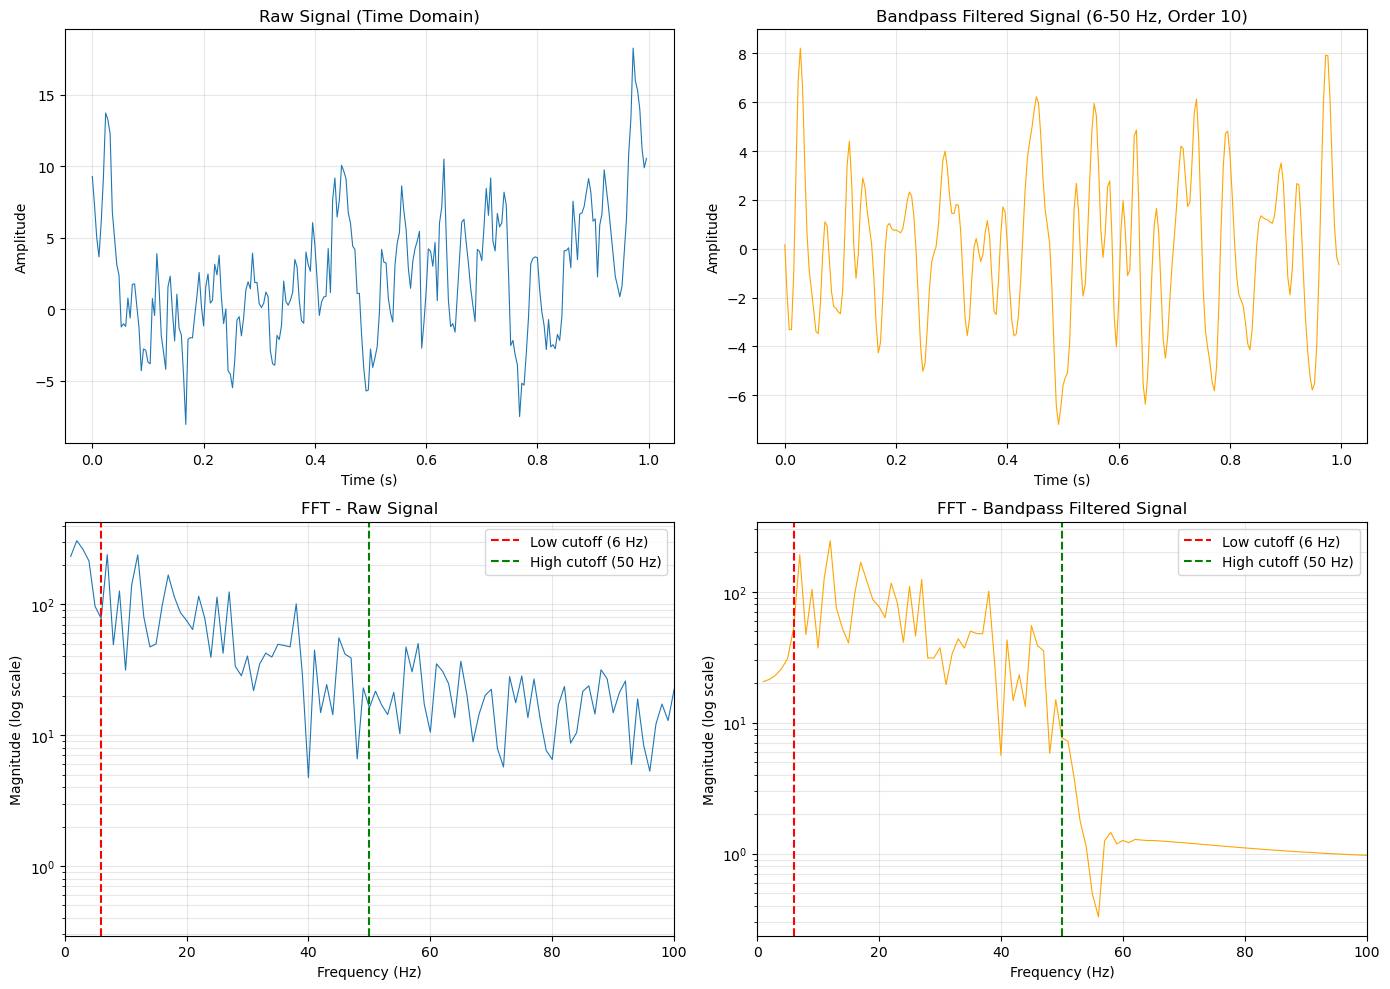


✓ Bandpass Filter Applied Successfully
  - Filter order: 10
  - Passband: 6-50 Hz
  - Raw signal energy (sum of squares): 6498.42
  - Filtered signal energy: 2395.42
  - Energy reduction: 63.1%


In [2]:
# Bandpass filter parameters (from run_cca_experiments.py and run_eegnet_experiments.py)
freq_cut_low = 6
freq_cut_high = 50
filter_order = 10

# Design the bandpass filter
b, a = scipy.signal.butter(
    filter_order,
    [freq_cut_low, freq_cut_high],
    btype="bandpass",
    analog=False,
    fs=sample_rate,
)

# Apply zero-phase filtering
filtered_signal_bandpass = scipy.signal.filtfilt(b, a, raw_signal)

# Compute FFT for both signals
fft_raw = np.abs(scipy.fft.fft(raw_signal))
fft_filtered = np.abs(scipy.fft.fft(filtered_signal_bandpass))
freqs = scipy.fft.fftfreq(len(raw_signal), 1/sample_rate)

# Only plot positive frequencies
positive_freq_idx = freqs > 0
freqs_pos = freqs[positive_freq_idx]
fft_raw_pos = fft_raw[positive_freq_idx]
fft_filtered_pos = fft_filtered[positive_freq_idx]

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time domain - Raw signal
axes[0, 0].plot(np.arange(len(raw_signal)) / sample_rate, raw_signal, linewidth=0.8)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].set_title('Raw Signal (Time Domain)')
axes[0, 0].grid(True, alpha=0.3)

# Time domain - Filtered signal
axes[0, 1].plot(np.arange(len(filtered_signal_bandpass)) / sample_rate, filtered_signal_bandpass, linewidth=0.8, color='orange')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].set_title('Bandpass Filtered Signal (6-50 Hz, Order 10)')
axes[0, 1].grid(True, alpha=0.3)

# Frequency domain - Raw signal
axes[1, 0].semilogy(freqs_pos, fft_raw_pos, linewidth=0.8)
axes[1, 0].axvline(freq_cut_low, color='r', linestyle='--', label=f'Low cutoff ({freq_cut_low} Hz)')
axes[1, 0].axvline(freq_cut_high, color='g', linestyle='--', label=f'High cutoff ({freq_cut_high} Hz)')
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_ylabel('Magnitude (log scale)')
axes[1, 0].set_title('FFT - Raw Signal')
axes[1, 0].set_xlim([0, 100])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, which='both')

# Frequency domain - Filtered signal
axes[1, 1].semilogy(freqs_pos, fft_filtered_pos, linewidth=0.8, color='orange')
axes[1, 1].axvline(freq_cut_low, color='r', linestyle='--', label=f'Low cutoff ({freq_cut_low} Hz)')
axes[1, 1].axvline(freq_cut_high, color='g', linestyle='--', label=f'High cutoff ({freq_cut_high} Hz)')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('Magnitude (log scale)')
axes[1, 1].set_title('FFT - Bandpass Filtered Signal')
axes[1, 1].set_xlim([0, 100])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f"\n✓ Bandpass Filter Applied Successfully")
print(f"  - Filter order: {filter_order}")
print(f"  - Passband: {freq_cut_low}-{freq_cut_high} Hz")
print(f"  - Raw signal energy (sum of squares): {np.sum(raw_signal**2):.2f}")
print(f"  - Filtered signal energy: {np.sum(filtered_signal_bandpass**2):.2f}")
print(f"  - Energy reduction: {(1 - np.sum(filtered_signal_bandpass**2) / np.sum(raw_signal**2)) * 100:.1f}%")

## 2. Subband Filter (3 Subbands)

This is the filter used in **DNN** experiments.
- **Type**: Multiple Chebyshev Type I bandpass filters
- **Number of subbands**: 3
- **High cutoff**: Fixed at 50 Hz
- **Low cutoffs**: 8 Hz, 16 Hz, 24 Hz (progressive)
- **Filter order**: 2
- **Passband ripple**: 1 dB
- **Method**: `filtfilt` (zero-phase filtering)

The DNN concatenates all subbands into a 4D tensor: [batch, subbands, channels, time]

Subband configuration:
  Subband 1: 8-50 Hz
  Subband 2: 16-50 Hz
  Subband 3: 24-50 Hz


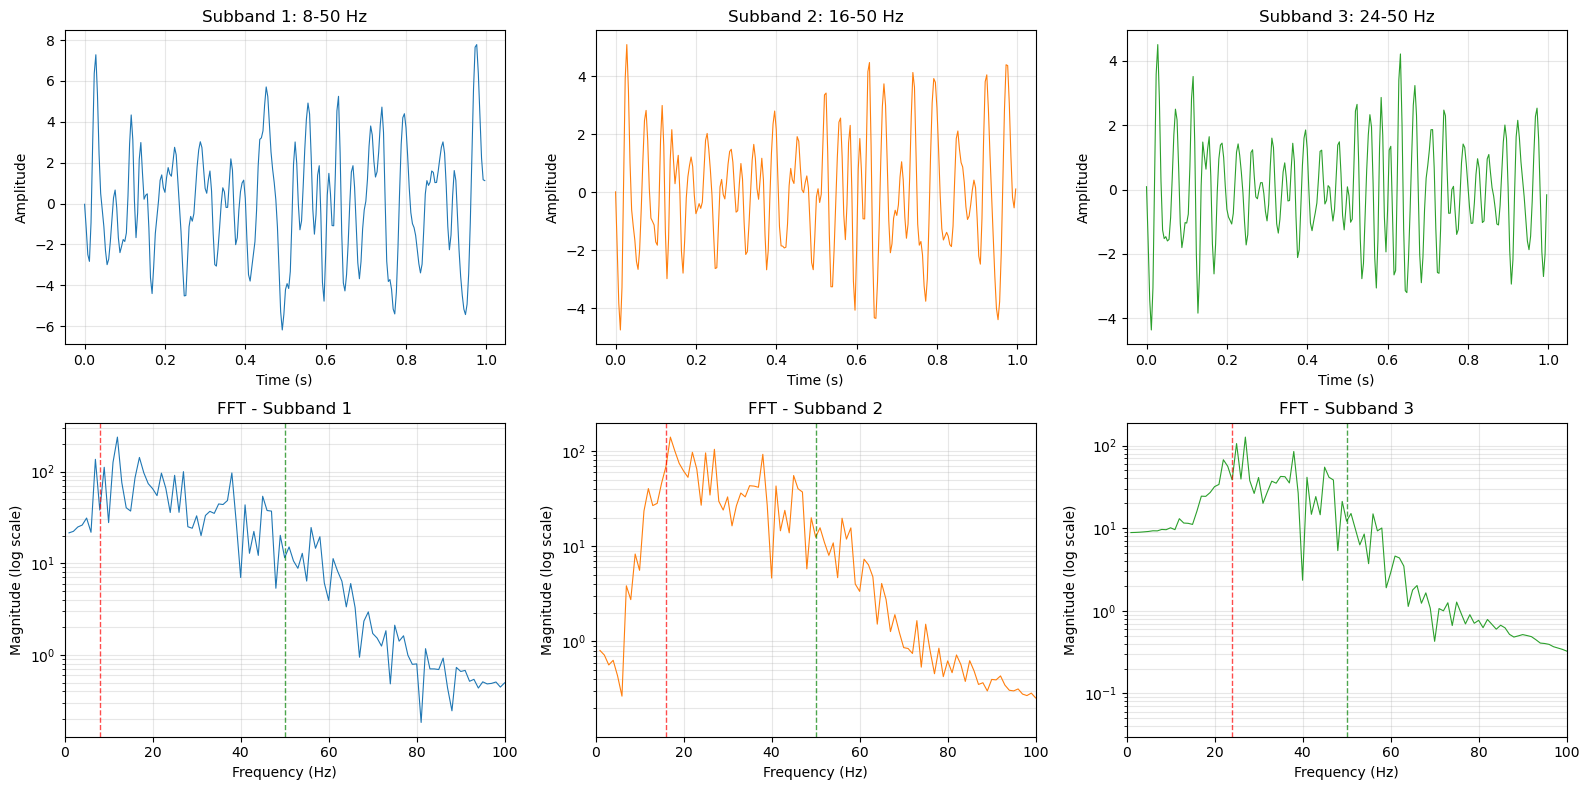


Energy Analysis for Subbands:
Raw signal energy: 6498.42
Subband 1 energy: 1886.19 (29.0% of raw)
Subband 2 energy: 957.91 (14.7% of raw)
Subband 3 energy: 594.67 (9.2% of raw)


In [3]:
# Subband filter parameters (from run_dnn_cross_experiments.py)
subban_no = 3
filter_order_subband = 2
passband_ripple = 1

# Design the Chebyshev filters for each subband
high_cutoff = [50] * subban_no
low_cutoff = [i for i in range(8, 8 * (subban_no + 1), 8)]

print("Subband configuration:")
for i in range(subban_no):
    print(f"  Subband {i+1}: {low_cutoff[i]}-{high_cutoff[i]} Hz")

# Apply filters to create subbands
filtered_subbands = np.zeros((subban_no, len(raw_signal)))

for i in range(subban_no):
    b, a = scipy.signal.cheby1(
        filter_order_subband,
        passband_ripple,
        [low_cutoff[i], high_cutoff[i]],
        btype="band",
        fs=sample_rate,
    )
    filtered_subbands[i] = scipy.signal.filtfilt(b, a, raw_signal)

# Compute FFT for all subbands
fig, axes = plt.subplots(2, subban_no, figsize=(16, 8))

# Plot time domain and frequency domain for each subband
for i in range(subban_no):
    # Time domain
    axes[0, i].plot(np.arange(len(raw_signal)) / sample_rate, filtered_subbands[i], linewidth=0.8, color=f'C{i}')
    axes[0, i].set_xlabel('Time (s)')
    axes[0, i].set_ylabel('Amplitude')
    axes[0, i].set_title(f'Subband {i+1}: {low_cutoff[i]}-{high_cutoff[i]} Hz')
    axes[0, i].grid(True, alpha=0.3)
    
    # Frequency domain
    fft_subband = np.abs(scipy.fft.fft(filtered_subbands[i]))
    axes[1, i].semilogy(freqs_pos, fft_subband[positive_freq_idx], linewidth=0.8, color=f'C{i}')
    axes[1, i].axvline(low_cutoff[i], color='r', linestyle='--', alpha=0.7, linewidth=1)
    axes[1, i].axvline(high_cutoff[i], color='g', linestyle='--', alpha=0.7, linewidth=1)
    axes[1, i].set_xlabel('Frequency (Hz)')
    axes[1, i].set_ylabel('Magnitude (log scale)')
    axes[1, i].set_title(f'FFT - Subband {i+1}')
    axes[1, i].set_xlim([0, 100])
    axes[1, i].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Energy analysis for subbands
print("\nEnergy Analysis for Subbands:")
print(f"Raw signal energy: {np.sum(raw_signal**2):.2f}")
for i in range(subban_no):
    energy = np.sum(filtered_subbands[i]**2)
    energy_pct = (energy / np.sum(raw_signal**2)) * 100
    print(f"Subband {i+1} energy: {energy:.2f} ({energy_pct:.1f}% of raw)")

## 3. CAR Filter (Common Average Reference) on Oz

This section applies **CAR** using all selected occipital electrodes, then analyzes the Oz channel before and after CAR.

- **Reference**: average of the 9 occipital electrodes
- **Target channel**: Oz (global channel index 61 in this setup)
- **Output**: time-domain and FFT comparison (with vs without CAR)

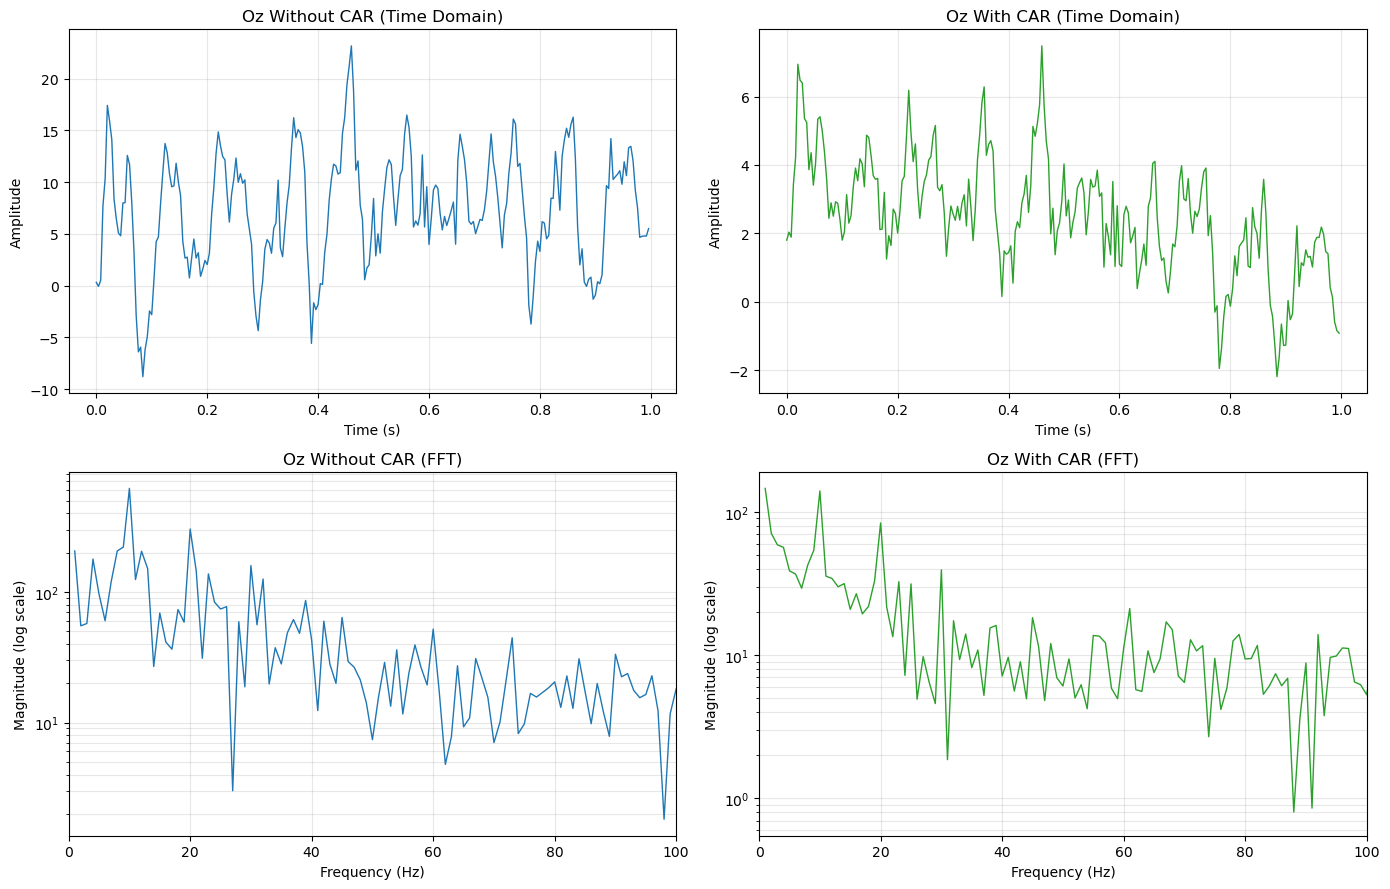


CAR FILTER SUMMARY (Oz)
--------------------------------------------------
Oz global channel index: 61
Oz local index inside occipital_electrodes: 7
RMS without CAR: 9.1101
RMS with CAR:    3.0211
Dominant freq without CAR (6-50 Hz): 10.00 Hz
Dominant freq with CAR (6-50 Hz):    10.00 Hz


In [7]:
# CAR filter analysis focused on electrode Oz
oz_global_channel = 61  # Oz in this dataset setup
oz_match = np.where(occipital_electrodes == oz_global_channel)[0]
if len(oz_match) == 0:
    raise ValueError(f"Oz channel ({oz_global_channel}) not found in occipital_electrodes")
oz_idx = oz_match[0]

# Extract all occipital channels for the same trial/window
raw_occipital_block = user_data[
    occipital_electrodes,
    delay:delay + window_size,
    freq_idx,
    session_idx,
].astype(float)

# Oz signal without CAR
oz_signal_no_car = raw_occipital_block[oz_idx]

# CAR reference = average across selected occipital channels
car_reference = np.mean(raw_occipital_block, axis=0)
oz_signal_car = oz_signal_no_car - car_reference

# FFT comparison
fft_oz_no_car = np.abs(scipy.fft.fft(oz_signal_no_car))
fft_oz_car = np.abs(scipy.fft.fft(oz_signal_car))
freqs_oz = scipy.fft.fftfreq(len(oz_signal_no_car), 1 / sample_rate)
positive_oz = freqs_oz > 0

# Plot time-domain and frequency-domain comparisons
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

time_axis = np.arange(len(oz_signal_no_car)) / sample_rate
axes[0, 0].plot(time_axis, oz_signal_no_car, linewidth=1.0, color='tab:blue')
axes[0, 0].set_title('Oz Without CAR (Time Domain)')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(time_axis, oz_signal_car, linewidth=1.0, color='tab:green')
axes[0, 1].set_title('Oz With CAR (Time Domain)')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].semilogy(freqs_oz[positive_oz], fft_oz_no_car[positive_oz], linewidth=1.0, color='tab:blue')
axes[1, 0].set_xlim([0, 100])
axes[1, 0].set_title('Oz Without CAR (FFT)')
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_ylabel('Magnitude (log scale)')
axes[1, 0].grid(True, alpha=0.3, which='both')

axes[1, 1].semilogy(freqs_oz[positive_oz], fft_oz_car[positive_oz], linewidth=1.0, color='tab:green')
axes[1, 1].set_xlim([0, 100])
axes[1, 1].set_title('Oz With CAR (FFT)')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('Magnitude (log scale)')
axes[1, 1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Print quick summary metrics in the SSVEP range
ssvep_band = (freqs_oz > 6) & (freqs_oz < 50)
dom_no_car = freqs_oz[ssvep_band][np.argmax(fft_oz_no_car[ssvep_band])]
dom_car = freqs_oz[ssvep_band][np.argmax(fft_oz_car[ssvep_band])]

print("\nCAR FILTER SUMMARY (Oz)")
print("-" * 50)
print(f"Oz global channel index: {oz_global_channel}")
print(f"Oz local index inside occipital_electrodes: {oz_idx}")
print(f"RMS without CAR: {np.sqrt(np.mean(oz_signal_no_car**2)):.4f}")
print(f"RMS with CAR:    {np.sqrt(np.mean(oz_signal_car**2)):.4f}")
print(f"Dominant freq without CAR (6-50 Hz): {dom_no_car:.2f} Hz")
print(f"Dominant freq with CAR (6-50 Hz):    {dom_car:.2f} Hz")

## 3.1 CAR Reference Choice: Occipital-Only vs All Electrodes

In SSVEP settings centered on visual cortex, CAR over **occipital channels** is often preferred because it preserves local posterior dynamics while reducing shared noise.

This cell compares three Oz variants across multiple frequencies:
- No CAR
- CAR with occipital-only reference
- CAR with all-electrodes reference

Decision rule for this notebook: keep the reference that best preserves the expected SSVEP peak while improving noise suppression (lower RMS and cleaner FFT baseline).

Testing CAR references at these frequencies:
  requested 10.40 Hz -> using 10.40 Hz (index 18)
  requested 15.60 Hz -> using 15.60 Hz (index 31)
  requested 12.20 Hz -> using 12.20 Hz (index 12)
  requested 9.80 Hz -> using 9.80 Hz (index 33)


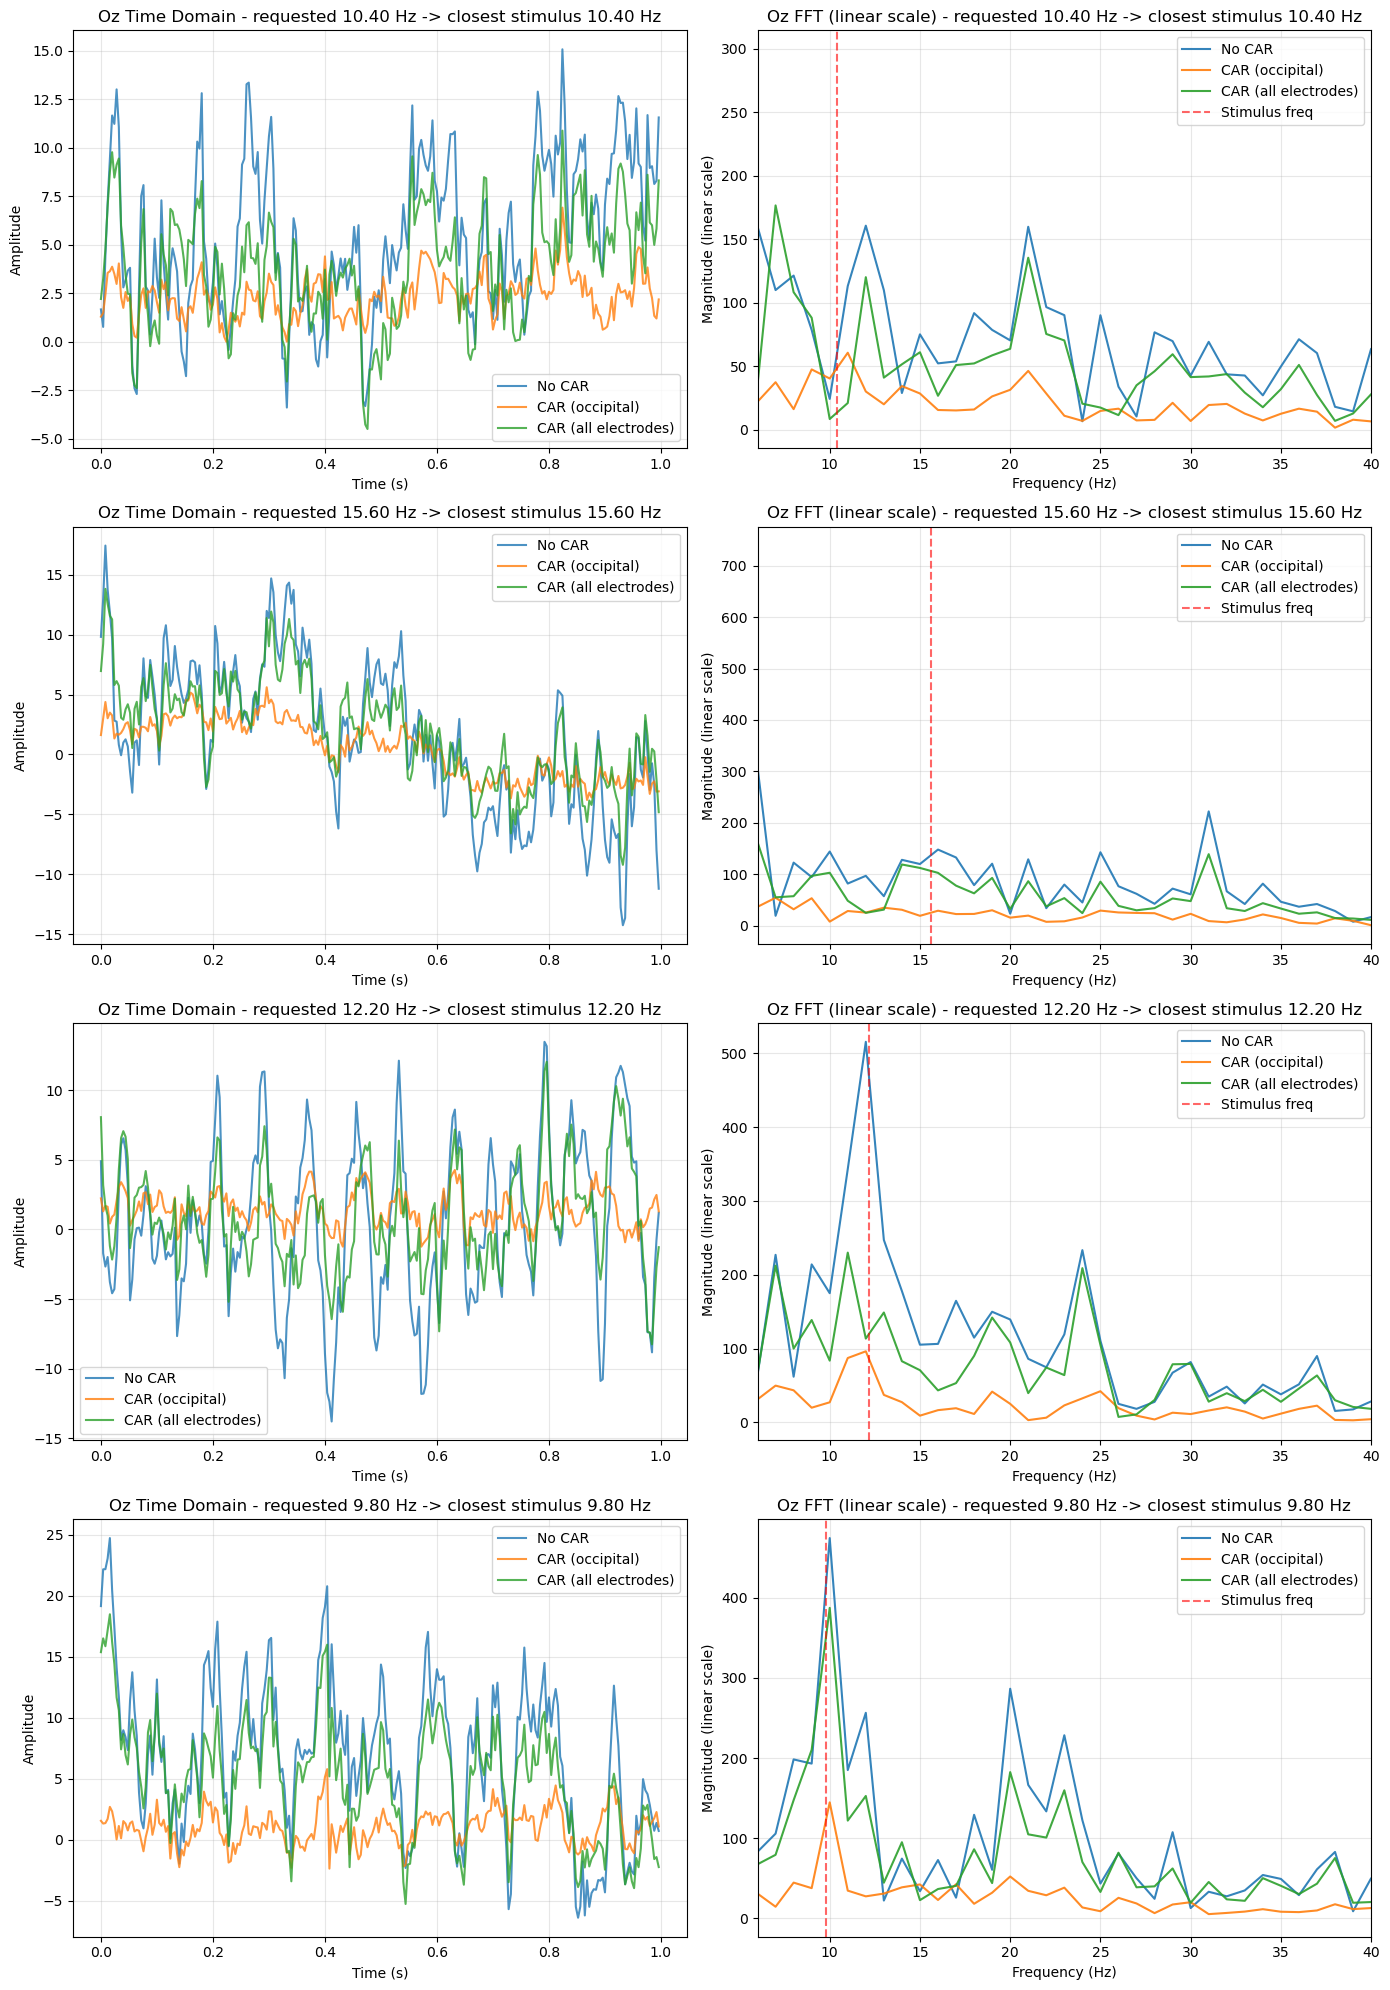


CAR REFERENCE COMPARISON SUMMARY (Oz)
----------------------------------------------------------------------------------------------------
Requested: 10.40 Hz | Used stimulus: 10.40 Hz
  RMS -> No CAR: 6.7541 | Occipital CAR: 2.6004 | All-electrodes CAR: 4.8306
  Dominant FFT(6-50 Hz) -> No CAR: 12.00 Hz | Occipital CAR: 11.00 Hz | All-electrodes CAR: 7.00 Hz
----------------------------------------------------------------------------------------------------
Requested: 15.60 Hz | Used stimulus: 15.60 Hz
  RMS -> No CAR: 6.2394 | Occipital CAR: 2.4289 | All-electrodes CAR: 4.6538
  Dominant FFT(6-50 Hz) -> No CAR: 31.00 Hz | Occipital CAR: 7.00 Hz | All-electrodes CAR: 31.00 Hz
----------------------------------------------------------------------------------------------------
Requested: 12.20 Hz | Used stimulus: 12.20 Hz
  RMS -> No CAR: 5.6618 | Occipital CAR: 1.8495 | All-electrodes CAR: 3.7863
  Dominant FFT(6-50 Hz) -> No CAR: 12.00 Hz | Occipital CAR: 12.00 Hz | All-electrodes CA

In [11]:
# Multi-frequency comparison: Oz with no CAR vs occipital-CAR vs all-electrodes-CAR
oz_global_channel = 61
oz_match = np.where(occipital_electrodes == oz_global_channel)[0]
if len(oz_match) == 0:
    raise ValueError(f"Oz channel ({oz_global_channel}) not found in occipital_electrodes")
oz_idx_occ = int(oz_match[0])

# User-requested frequencies
requested_freqs = [10.4, 15.6, 12.2, 9.8]
selected_indices = [int(np.argmin(np.abs(frequencias - rf))) for rf in requested_freqs]
selected_labels = [
    f"requested {rf:.2f} Hz -> closest stimulus {frequencias[idx]:.2f} Hz"
    for rf, idx in zip(requested_freqs, selected_indices)
]

print("Testing CAR references at these frequencies:")
for rf, idx in zip(requested_freqs, selected_indices):
    print(f"  requested {rf:.2f} Hz -> using {frequencias[idx]:.2f} Hz (index {idx})")

fig, axes = plt.subplots(len(selected_indices), 2, figsize=(14, 5 * len(selected_indices)))
if len(selected_indices) == 1:
    axes = np.array([axes])

summary_rows = []

for row_i, (f_idx, f_label) in enumerate(zip(selected_indices, selected_labels)):
    raw_occ = user_data[occipital_electrodes, delay:delay + window_size, f_idx, session_idx].astype(float)
    raw_all = user_data[:, delay:delay + window_size, f_idx, session_idx].astype(float)

    oz_no_car = raw_occ[oz_idx_occ]
    oz_car_occ = oz_no_car - np.mean(raw_occ, axis=0)
    oz_car_all = oz_no_car - np.mean(raw_all, axis=0)

    # Time domain overlay
    t_axis = np.arange(len(oz_no_car)) / sample_rate
    axes[row_i, 0].plot(t_axis, oz_no_car, label='No CAR', alpha=0.8)
    axes[row_i, 0].plot(t_axis, oz_car_occ, label='CAR (occipital)', alpha=0.8)
    axes[row_i, 0].plot(t_axis, oz_car_all, label='CAR (all electrodes)', alpha=0.8)
    axes[row_i, 0].set_title(f'Oz Time Domain - {f_label}')
    axes[row_i, 0].set_xlabel('Time (s)')
    axes[row_i, 0].set_ylabel('Amplitude')
    axes[row_i, 0].grid(True, alpha=0.3)
    axes[row_i, 0].legend()

    # FFT comparison on normal (linear) scale to highlight peaks
    f_axis = scipy.fft.fftfreq(len(oz_no_car), 1 / sample_rate)
    pos = f_axis > 0
    f_pos = f_axis[pos]
    fft_no = np.abs(scipy.fft.fft(oz_no_car))
    fft_occ = np.abs(scipy.fft.fft(oz_car_occ))
    fft_all = np.abs(scipy.fft.fft(oz_car_all))

    axes[row_i, 1].plot(f_pos, fft_no[pos], label='No CAR', alpha=0.9)
    axes[row_i, 1].plot(f_pos, fft_occ[pos], label='CAR (occipital)', alpha=0.9)
    axes[row_i, 1].plot(f_pos, fft_all[pos], label='CAR (all electrodes)', alpha=0.9)
    axes[row_i, 1].axvline(frequencias[f_idx], color='r', linestyle='--', alpha=0.6, label='Stimulus freq')
    axes[row_i, 1].set_xlim([6, 40])
    axes[row_i, 1].set_title(f'Oz FFT (linear scale) - {f_label}')
    axes[row_i, 1].set_xlabel('Frequency (Hz)')
    axes[row_i, 1].set_ylabel('Magnitude (linear scale)')
    axes[row_i, 1].grid(True, alpha=0.3)
    axes[row_i, 1].legend()

    ssvep_band = (f_axis > 6) & (f_axis < 50)
    dom_no = f_axis[ssvep_band][np.argmax(fft_no[ssvep_band])]
    dom_occ = f_axis[ssvep_band][np.argmax(fft_occ[ssvep_band])]
    dom_all = f_axis[ssvep_band][np.argmax(fft_all[ssvep_band])]

    summary_rows.append(
        {
            'requested_hz': float(requested_freqs[row_i]),
            'stimulus_hz': float(frequencias[f_idx]),
            'rms_no_car': float(np.sqrt(np.mean(oz_no_car ** 2))),
            'rms_car_occ': float(np.sqrt(np.mean(oz_car_occ ** 2))),
            'rms_car_all': float(np.sqrt(np.mean(oz_car_all ** 2))),
            'dom_no_car': float(dom_no),
            'dom_car_occ': float(dom_occ),
            'dom_car_all': float(dom_all),
        }
    )

plt.tight_layout()
plt.show()

print('\nCAR REFERENCE COMPARISON SUMMARY (Oz)')
print('-' * 100)
for row in summary_rows:
    print(f"Requested: {row['requested_hz']:.2f} Hz | Used stimulus: {row['stimulus_hz']:.2f} Hz")
    print(f"  RMS -> No CAR: {row['rms_no_car']:.4f} | Occipital CAR: {row['rms_car_occ']:.4f} | All-electrodes CAR: {row['rms_car_all']:.4f}")
    print(f"  Dominant FFT(6-50 Hz) -> No CAR: {row['dom_no_car']:.2f} Hz | Occipital CAR: {row['dom_car_occ']:.2f} Hz | All-electrodes CAR: {row['dom_car_all']:.2f} Hz")
    print('-' * 100)

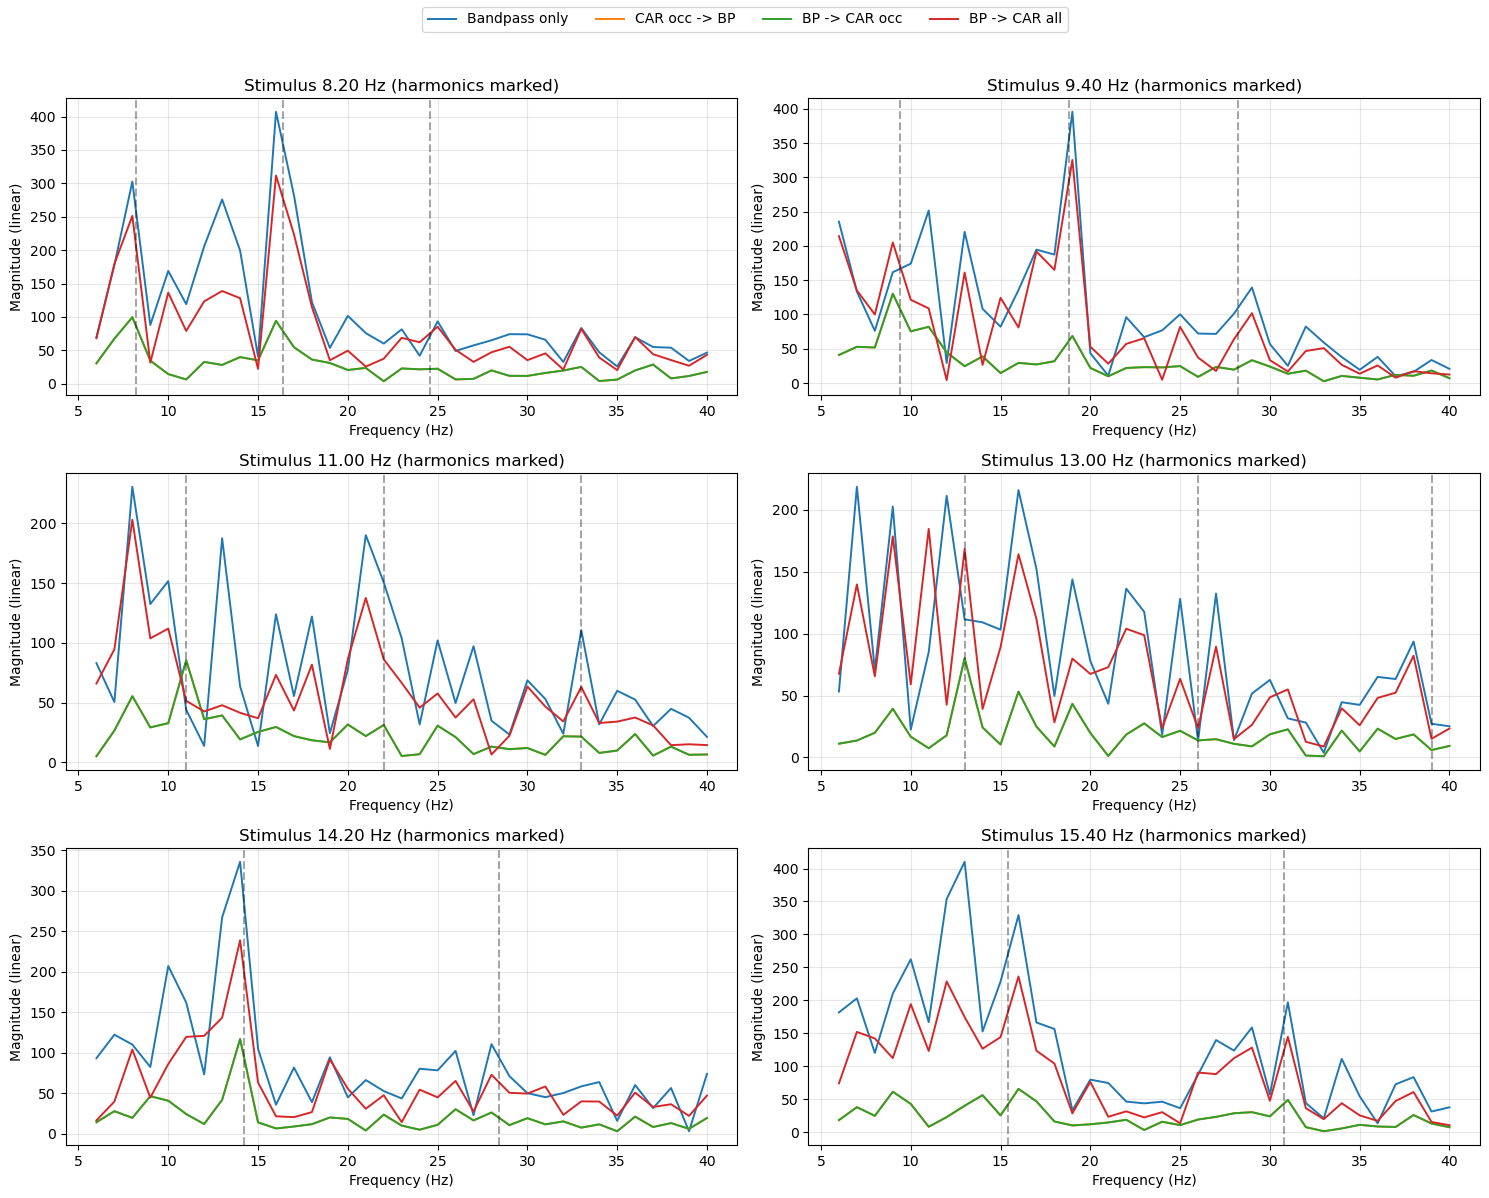


ORDER CHECK (CAR before/after BP)
--------------------------------------------------------------------------------
Max abs diff, occipital CAR order: 3.3815e-04 (mean), 6.1948e-04 (max)
Max abs diff, all-electrode CAR order: 4.0050e-04 (mean), 8.5396e-04 (max)

CCA-ORIENTED METRICS (higher is better)
--------------------------------------------------------------------------------
BP -> CAR all   | mean CCA-like score: 0.4867 | mean harmonic contrast: 3.92 dB
BP -> CAR occ   | mean CCA-like score: 0.5833 | mean harmonic contrast: 4.66 dB
Bandpass only   | mean CCA-like score: 0.4364 | mean harmonic contrast: 2.89 dB
CAR all -> BP   | mean CCA-like score: 0.4867 | mean harmonic contrast: 3.92 dB
CAR occ -> BP   | mean CCA-like score: 0.5833 | mean harmonic contrast: 4.66 dB
Raw Oz          | mean CCA-like score: 0.3469 | mean harmonic contrast: 2.27 dB

Per-frequency top method by CCA-like score:
--------------------------------------------------------------------------------
Stimulus 8

In [13]:
# CCA-oriented analysis across additional frequencies and processing orders
from numpy.linalg import lstsq

oz_global_channel = 61
oz_match = np.where(occipital_electrodes == oz_global_channel)[0]
if len(oz_match) == 0:
    raise ValueError(f"Oz channel ({oz_global_channel}) not found in occipital_electrodes")
oz_idx_occ = int(oz_match[0])

# Additional frequencies to validate conclusions (different from previous set)
requested_freqs_extra = [8.2, 9.4, 11.0, 13.0, 14.2, 15.4]
selected_indices_extra = [int(np.argmin(np.abs(frequencias - rf))) for rf in requested_freqs_extra]

# Bandpass used in CCA experiments
b_bp, a_bp = scipy.signal.butter(
    filter_order,
    [freq_cut_low, freq_cut_high],
    btype="bandpass",
    fs=sample_rate,
    analog=False,
)

def cca_like_score(sig, f0, fs, n_harm=3):
    """
    CCA-like score for one channel: multiple correlation between signal and
    sine/cosine harmonic reference bank.
    """
    t = np.arange(len(sig)) / fs
    cols = []
    for h in range(1, n_harm + 1):
        if h * f0 < fs / 2:
            cols.append(np.sin(2 * np.pi * h * f0 * t))
            cols.append(np.cos(2 * np.pi * h * f0 * t))
    X = np.column_stack(cols)
    y = sig - np.mean(sig)
    y_std = np.std(y) + 1e-12
    y = y / y_std

    # Standardize reference columns
    X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-12)
    beta, *_ = lstsq(X, y, rcond=None)
    y_hat = X @ beta
    score = np.corrcoef(y, y_hat)[0, 1]
    return float(np.abs(score))

def harmonic_contrast_db(sig, f0, fs, n_harm=3, max_hz=50):
    """
    Contrast of harmonic bins against local neighboring bins (in dB).
    Higher is better for frequency-based discrimination.
    """
    spec = np.abs(np.fft.rfft(sig))
    f = np.fft.rfftfreq(len(sig), 1 / fs)
    contrasts = []
    for h in range(1, n_harm + 1):
        fh = h * f0
        if fh > max_hz:
            continue
        k = int(np.argmin(np.abs(f - fh)))

        sig_lo = max(0, k - 1)
        sig_hi = min(len(spec), k + 2)
        signal_mag = np.mean(spec[sig_lo:sig_hi])

        left_lo = max(0, k - 6)
        left_hi = max(0, k - 2)
        right_lo = min(len(spec), k + 2)
        right_hi = min(len(spec), k + 6)
        noise_bins = np.concatenate([spec[left_lo:left_hi], spec[right_lo:right_hi]])
        noise_mag = np.mean(noise_bins) if len(noise_bins) > 0 else 1e-12
        contrasts.append(20 * np.log10((signal_mag + 1e-12) / (noise_mag + 1e-12)))

    return float(np.mean(contrasts)) if len(contrasts) > 0 else np.nan

rows = []
order_diff_occ = []
order_diff_all = []

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for i, f_idx in enumerate(selected_indices_extra):
    f0 = float(frequencias[f_idx])
    raw_occ = user_data[occipital_electrodes, delay:delay + window_size, f_idx, session_idx].astype(float)
    raw_all = user_data[:, delay:delay + window_size, f_idx, session_idx].astype(float)

    # Base signals
    oz_raw = raw_occ[oz_idx_occ]

    # Bandpass only
    oz_bp = scipy.signal.filtfilt(b_bp, a_bp, oz_raw)

    # Occipital CAR before / after BP
    oz_car_occ_pre = oz_raw - np.mean(raw_occ, axis=0)
    oz_car_occ_pre_bp = scipy.signal.filtfilt(b_bp, a_bp, oz_car_occ_pre)
    occ_bp = scipy.signal.filtfilt(b_bp, a_bp, raw_occ, axis=1)
    oz_bp_car_occ = occ_bp[oz_idx_occ] - np.mean(occ_bp, axis=0)

    # All-electrodes CAR before / after BP
    oz_car_all_pre = oz_raw - np.mean(raw_all, axis=0)
    oz_car_all_pre_bp = scipy.signal.filtfilt(b_bp, a_bp, oz_car_all_pre)
    all_bp = scipy.signal.filtfilt(b_bp, a_bp, raw_all, axis=1)
    oz_bp_car_all = all_bp[oz_global_channel] - np.mean(all_bp, axis=0)

    order_diff_occ.append(np.max(np.abs(oz_car_occ_pre_bp - oz_bp_car_occ)))
    order_diff_all.append(np.max(np.abs(oz_car_all_pre_bp - oz_bp_car_all)))

    methods = {
        "Raw Oz": oz_raw,
        "Bandpass only": oz_bp,
        "CAR occ -> BP": oz_car_occ_pre_bp,
        "BP -> CAR occ": oz_bp_car_occ,
        "CAR all -> BP": oz_car_all_pre_bp,
        "BP -> CAR all": oz_bp_car_all,
    }

    # Plot FFT (linear scale) focused on 6-40 Hz
    ax = axes[i]
    f_fft = np.fft.rfftfreq(len(oz_raw), 1 / sample_rate)
    mask = (f_fft >= 6) & (f_fft <= 40)
    for name in ["Bandpass only", "CAR occ -> BP", "BP -> CAR occ", "BP -> CAR all"]:
        s = methods[name]
        mag = np.abs(np.fft.rfft(s))
        ax.plot(f_fft[mask], mag[mask], label=name, linewidth=1.4)

    for h in [1, 2, 3]:
        fh = h * f0
        if fh <= 40:
            ax.axvline(fh, linestyle='--', alpha=0.35, color='k')
    ax.set_title(f"Stimulus {f0:.2f} Hz (harmonics marked)")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude (linear)")
    ax.grid(True, alpha=0.3)

    for method_name, sig in methods.items():
        rows.append(
            {
                "stimulus_hz": f0,
                "method": method_name,
                "cca_score": cca_like_score(sig, f0, sample_rate, n_harm=3),
                "harmonic_contrast_db": harmonic_contrast_db(sig, f0, sample_rate, n_harm=3, max_hz=50),
            }
        )

for j in range(len(selected_indices_extra), len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Summaries
print("\nORDER CHECK (CAR before/after BP)")
print("-" * 80)
print(f"Max abs diff, occipital CAR order: {np.mean(order_diff_occ):.4e} (mean), {np.max(order_diff_occ):.4e} (max)")
print(f"Max abs diff, all-electrode CAR order: {np.mean(order_diff_all):.4e} (mean), {np.max(order_diff_all):.4e} (max)")

print("\nCCA-ORIENTED METRICS (higher is better)")
print("-" * 80)
methods_unique = sorted(list(set(r['method'] for r in rows)))
for m in methods_unique:
    subset = [r for r in rows if r['method'] == m]
    mean_cca = np.mean([r['cca_score'] for r in subset])
    mean_hc = np.mean([r['harmonic_contrast_db'] for r in subset])
    print(f"{m:15s} | mean CCA-like score: {mean_cca:.4f} | mean harmonic contrast: {mean_hc:.2f} dB")

print("\nPer-frequency top method by CCA-like score:")
print("-" * 80)
for f0 in sorted(list(set(r['stimulus_hz'] for r in rows))):
    subset = [r for r in rows if r['stimulus_hz'] == f0]
    best = sorted(subset, key=lambda x: x['cca_score'], reverse=True)[0]
    print(f"Stimulus {f0:.2f} Hz -> {best['method']} (CCA-like score {best['cca_score']:.4f}, harmonic contrast {best['harmonic_contrast_db']:.2f} dB)")

## 3.3 Real CCA Classification Test (using `cca.py`)

The previous **CCA-like score** was only a proxy (single-signal regression correlation against harmonic references).
It is useful for trend inspection, but it is **not** the exact CCA classifier used in experiments.

Below we run **real CCA** with `CCA()` and `reference_matrix()` from `cross-subject/cca.py`,
and evaluate frequency classification accuracy across multiple sessions.

Classification protocol:
- Candidate classes: selected stimulus frequencies
- Input EEG: occipital channels
- Methods compared: Bandpass only, CAR occ -> BP, BP -> CAR occ, BP -> CAR all
- Decision rule: class with highest CCA correlation

CCA classification classes (requested -> used):
  8.20 Hz -> 8.20 Hz
  9.40 Hz -> 9.40 Hz
  10.40 Hz -> 10.40 Hz
  11.00 Hz -> 11.00 Hz
  12.20 Hz -> 12.20 Hz
  13.00 Hz -> 13.00 Hz
  14.20 Hz -> 14.20 Hz
  15.40 Hz -> 15.40 Hz

REAL CCA CLASSIFICATION RESULTS
Bandpass only   | accuracy:  85.42% | mean corr margin: 0.0898
CAR occ -> BP   | accuracy:  83.33% | mean corr margin: 0.0994
BP -> CAR occ   | accuracy:  83.33% | mean corr margin: 0.0995
BP -> CAR all   | accuracy:  75.00% | mean corr margin: 0.0900

Best method: Bandpass only
Confusion matrix (rows=true, cols=pred):
[[6 0 0 0 0 0 0 0]
 [0 6 0 0 0 0 0 0]
 [0 0 6 0 0 0 0 0]
 [0 0 0 6 0 0 0 0]
 [0 0 0 1 5 0 0 0]
 [0 0 0 0 1 5 0 0]
 [0 0 0 0 1 0 5 0]
 [1 0 0 0 1 2 0 2]]


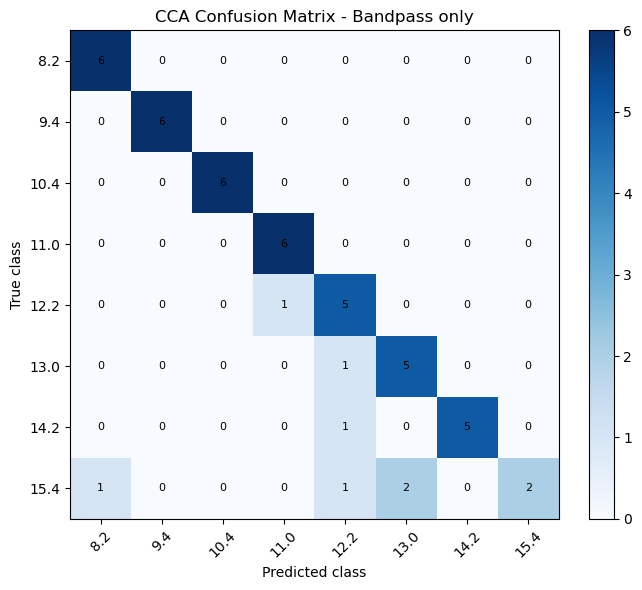

In [15]:
# Real CCA classification benchmark using cross-subject/cca.py
import sys
from pathlib import Path

# Locate and import CCA utilities from cross-subject/cca.py
cwd = Path.cwd().resolve()
search_roots = [cwd] + list(cwd.parents)
project_root = None
for p in search_roots:
    if (p / "cca.py").exists():
        project_root = p
        break
if project_root is None:
    raise FileNotFoundError("Could not locate cca.py from current notebook working directory")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from cca import CCA, reference_matrix

# Candidate frequencies for classification
requested_freqs_cls = [8.2, 9.4, 10.4, 11.0, 12.2, 13.0, 14.2, 15.4]
candidate_indices = [int(np.argmin(np.abs(frequencias - rf))) for rf in requested_freqs_cls]
candidate_freqs = [float(frequencias[idx]) for idx in candidate_indices]

print("CCA classification classes (requested -> used):")
for rf, uf in zip(requested_freqs_cls, candidate_freqs):
    print(f"  {rf:.2f} Hz -> {uf:.2f} Hz")

n_sessions = user_data.shape[3]
n_harm = 3
rng = np.random.default_rng(123)

# Precompute CCA references
ref_cache = {}
for f0 in candidate_freqs:
    ref_cache[f0] = reference_matrix(
        numero_de_harmonicas=n_harm,
        fase_inicial=0,
        sessoes=1,
        frequencia=f0,
        fase=0,
        numero_de_amostras=window_size,
    )

def prep_bandpass_only(raw_occ, raw_all):
    return scipy.signal.filtfilt(b_bp, a_bp, raw_occ, axis=1)

def prep_car_occ_then_bp(raw_occ, raw_all):
    x = raw_occ - np.mean(raw_occ, axis=0, keepdims=True)
    return scipy.signal.filtfilt(b_bp, a_bp, x, axis=1)

def prep_bp_then_car_occ(raw_occ, raw_all):
    x = scipy.signal.filtfilt(b_bp, a_bp, raw_occ, axis=1)
    return x - np.mean(x, axis=0, keepdims=True)

def prep_bp_then_car_all(raw_occ, raw_all):
    x_all = scipy.signal.filtfilt(b_bp, a_bp, raw_all, axis=1)
    x_occ = x_all[occipital_electrodes]
    return x_occ - np.mean(x_all, axis=0, keepdims=True)

methods = {
    "Bandpass only": prep_bandpass_only,
    "CAR occ -> BP": prep_car_occ_then_bp,
    "BP -> CAR occ": prep_bp_then_car_occ,
    "BP -> CAR all": prep_bp_then_car_all,
}

def safe_cca_corr(X_occ, Y_ref):
    # Keep using cca.py's CCA, but retry with tiny jitter to avoid occasional SVD non-convergence
    for eps in [0.0, 1e-10, 1e-8, 1e-6, 1e-4]:
        try:
            if eps > 0:
                X_try = X_occ + eps * rng.standard_normal(X_occ.shape)
            else:
                X_try = X_occ
            _, _, corr = CCA(X_try, Y_ref)
            corr_val = float(np.real(corr))
            if np.isfinite(corr_val):
                return corr_val
        except Exception:
            continue
    return -1e9

def classify_trial(X_occ):
    # X_occ shape: (n_channels, n_timepoints)
    corrs = []
    for f0 in candidate_freqs:
        Y = ref_cache[f0]
        corrs.append(safe_cca_corr(X_occ, Y))
    corrs = np.array(corrs)
    pred_idx = int(np.argmax(corrs))
    sorted_corrs = np.sort(corrs)[::-1]
    margin = float(sorted_corrs[0] - sorted_corrs[1]) if len(sorted_corrs) > 1 else 0.0
    return pred_idx, corrs, margin

results = {}
for method_name, fn in methods.items():
    y_true = []
    y_pred = []
    margins = []

    for cls_i, f_idx in enumerate(candidate_indices):
        for sess in range(n_sessions):
            raw_occ = user_data[occipital_electrodes, delay:delay + window_size, f_idx, sess].astype(float)
            raw_all = user_data[:, delay:delay + window_size, f_idx, sess].astype(float)

            X_proc = fn(raw_occ, raw_all)
            pred_i, _, margin = classify_trial(X_proc)

            y_true.append(cls_i)
            y_pred.append(pred_i)
            margins.append(margin)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = float(np.mean(y_true == y_pred))

    # Confusion matrix
    n_cls = len(candidate_indices)
    cm = np.zeros((n_cls, n_cls), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    results[method_name] = {
        "accuracy": acc,
        "mean_margin": float(np.mean(margins)),
        "confusion": cm,
    }

print("\nREAL CCA CLASSIFICATION RESULTS")
print("=" * 90)
for method_name, info in results.items():
    print(f"{method_name:15s} | accuracy: {info['accuracy']*100:6.2f}% | mean corr margin: {info['mean_margin']:.4f}")

# Show best method confusion matrix
best_method = sorted(results.items(), key=lambda kv: kv[1]["accuracy"], reverse=True)[0][0]
best_cm = results[best_method]["confusion"]

print("\nBest method:", best_method)
print("Confusion matrix (rows=true, cols=pred):")
print(best_cm)

# Visualize confusion matrix for best method
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(best_cm, cmap="Blues")
ax.set_title(f"CCA Confusion Matrix - {best_method}")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticks(np.arange(len(candidate_freqs)))
ax.set_yticks(np.arange(len(candidate_freqs)))
ax.set_xticklabels([f"{f:.1f}" for f in candidate_freqs], rotation=45)
ax.set_yticklabels([f"{f:.1f}" for f in candidate_freqs])

for i in range(best_cm.shape[0]):
    for j in range(best_cm.shape[1]):
        ax.text(j, i, str(best_cm[i, j]), ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Running full CCA benchmark with:
  users: 35
  frequencies: 40
  harmonics: 3
  window size: 250 samples (1.0 s)


Carregando dados dos usuarios: 100%|██████████| 35/35 [01:53<00:00,  3.26s/it]


User 01 -> Acc: 0.4000 | Recall: 0.4000 | F1: 0.3938
User 02 -> Acc: 0.6083 | Recall: 0.6083 | F1: 0.5907
User 03 -> Acc: 0.7792 | Recall: 0.7792 | F1: 0.7707
User 04 -> Acc: 0.8667 | Recall: 0.8667 | F1: 0.8630
User 05 -> Acc: 0.5208 | Recall: 0.5208 | F1: 0.5168
User 06 -> Acc: 0.4625 | Recall: 0.4625 | F1: 0.4614
User 07 -> Acc: 0.3958 | Recall: 0.3958 | F1: 0.3913
User 08 -> Acc: 0.2417 | Recall: 0.2417 | F1: 0.2171
User 09 -> Acc: 0.4500 | Recall: 0.4500 | F1: 0.4398
User 10 -> Acc: 0.4167 | Recall: 0.4167 | F1: 0.4191
User 11 -> Acc: 0.1458 | Recall: 0.1458 | F1: 0.1355
User 12 -> Acc: 0.7458 | Recall: 0.7458 | F1: 0.7385
User 13 -> Acc: 0.3917 | Recall: 0.3917 | F1: 0.3617
User 14 -> Acc: 0.6333 | Recall: 0.6333 | F1: 0.6183
User 15 -> Acc: 0.3458 | Recall: 0.3458 | F1: 0.3305
User 16 -> Acc: 0.1625 | Recall: 0.1625 | F1: 0.1613
User 17 -> Acc: 0.4125 | Recall: 0.4125 | F1: 0.3958
User 18 -> Acc: 0.4375 | Recall: 0.4375 | F1: 0.4289
User 19 -> Acc: 0.1292 | Recall: 0.1292 | F1: 

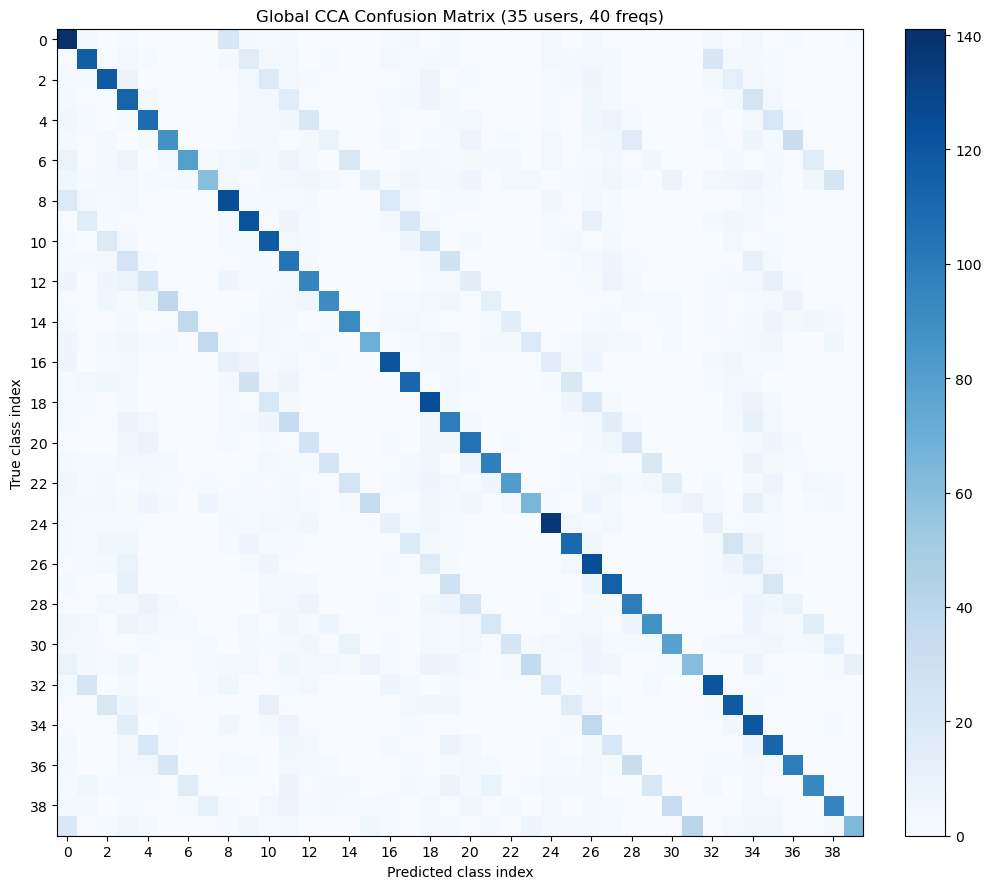


Per-user accuracy summary:
  mean=0.4857, std=0.2022, min=0.1292, max=0.8667


In [16]:
# Full cross-subject CCA evaluation based on run_cca_experiments.py
import sys
from pathlib import Path
from sklearn.metrics import confusion_matrix, f1_score, recall_score, accuracy_score

# Ensure imports from cross-subject root are available
cwd = Path.cwd().resolve()
search_roots = [cwd] + list(cwd.parents)
project_root = None
for p in search_roots:
    if (p / "run_cca_experiments.py").exists() and (p / "cross_subject_utils.py").exists():
        project_root = p
        break
if project_root is None:
    raise FileNotFoundError("Could not locate cross-subject project root")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from cca import CCA, reference_matrix
from cross_subject_utils import load_data_from_users

def evaluate_metrics(all_labels, all_preds):
    acc = accuracy_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    cm = confusion_matrix(all_labels, all_preds)
    return acc, rec, f1, cm

# Configuration aligned with run_cca_experiments.py
sample_rate = 250
filter_order = 10
freq_cut_high = 50
freq_cut_low = 6
delay = 160
num_harmonica = 3
inform_fase = 0
users = list(range(1, 36))
occipital_electrodes = np.array([47, 53, 54, 55, 56, 57, 60, 61, 62])
window_size_sec = 1.0
window_size = int(np.ceil(window_size_sec * sample_rate))

# All 40 frequencies
frequencias_desejadas = frequencias
indices = list(range(len(frequencias_desejadas)))

print("Running full CCA benchmark with:")
print(f"  users: {len(users)}")
print(f"  frequencies: {len(indices)}")
print(f"  harmonics: {num_harmonica}")
print(f"  window size: {window_size} samples ({window_size_sec:.1f} s)")

# Load all users with same preprocessing as script (bandpass enabled)
all_data = load_data_from_users(
    dataset_path="/home/mateuschinelatto/Experiments/data/benchmark/",
    users=users,
    visual_delay=delay,
    filter_bandpass=True,
    sample_rate=sample_rate,
    freq_cut_low=freq_cut_low,
    freq_cut_high=freq_cut_high,
    filter_order=filter_order,
)

# Build CCA references once
Y_ref = np.zeros((num_harmonica * 2, window_size, len(indices)))
for k, idx in enumerate(indices):
    y = reference_matrix(
        num_harmonica,
        inform_fase,
        1,
        frequencias[idx],
        fases,
        window_size,
    )
    Y_ref[:, :, k] = y

all_labels_global = []
all_preds_global = []
per_user_metrics = []

for test_user_idx, test_user in enumerate(users):
    test_data = all_data[test_user_idx]
    num_trials_test = test_data.shape[-1]

    labels = []
    preds = []

    for k, idx in enumerate(indices):
        for sess in range(num_trials_test):
            eeg_matrix = test_data[
                occipital_electrodes, :window_size, idx, sess
            ]
            corrs = np.zeros(len(indices), dtype=float)

            for f in range(len(indices)):
                _, _, corr = CCA(eeg_matrix, Y_ref[:, :, f])
                corr_val = float(np.real(corr))
                corrs[f] = corr_val if np.isfinite(corr_val) else -1e9

            pred_label = int(np.argmax(corrs))
            labels.append(idx)
            preds.append(indices[pred_label])

    acc_u, rec_u, f1_u, _ = evaluate_metrics(labels, preds)
    per_user_metrics.append((test_user, acc_u, rec_u, f1_u))
    all_labels_global.extend(labels)
    all_preds_global.extend(preds)

    print(f"User {test_user:02d} -> Acc: {acc_u:.4f} | Recall: {rec_u:.4f} | F1: {f1_u:.4f}")

acc_g, rec_g, f1_g, cm_g = evaluate_metrics(all_labels_global, all_preds_global)

print("\nGLOBAL RESULTS (all users, all 40 frequencies)")
print("=" * 90)
print(f"Accuracy: {acc_g:.4f}")
print(f"Recall:   {rec_g:.4f}")
print(f"F1-score: {f1_g:.4f}")

# Plot global confusion matrix
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm_g, cmap="Blues")
ax.set_title("Global CCA Confusion Matrix (35 users, 40 freqs)")
ax.set_xlabel("Predicted class index")
ax.set_ylabel("True class index")
ax.set_xticks(np.arange(0, len(indices), 2))
ax.set_yticks(np.arange(0, len(indices), 2))
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Summary table for user metrics
acc_values = np.array([m[1] for m in per_user_metrics])
print("\nPer-user accuracy summary:")
print(f"  mean={acc_values.mean():.4f}, std={acc_values.std():.4f}, min={acc_values.min():.4f}, max={acc_values.max():.4f}")

## 3.4 Full Cross-Subject CCA Benchmark (as in `run_cca_experiments.py`)

This section reproduces the core CCA configuration from the training script with:
- **3 harmonics**
- **1.0 s window** (250 samples)
- **All 40 stimulus frequencies**
- **All users (1 to 35)**

It reports per-user and global accuracy/recall/F1, plus a global confusion matrix.

## 3.2 CCA-Oriented Comparison: CAR/Bandpass Order and Harmonic Emphasis

This section evaluates whether CAR should be applied before or after bandpass filtering for CCA-style frequency detection.

Because both CAR and Butterworth filtering are linear operations, their order is expected to be nearly equivalent in practice (up to small numerical/edge differences).

Instead of RMS, we use CCA-relevant metrics:
- **CCA-like reference correlation** with sine/cosine references at harmonics
- **Harmonic contrast score** (stimulus harmonics vs neighboring spectral bins)

## Comparison: All Filters Together

Side-by-side comparison of raw signal, bandpass filtered signal, and subband decomposition.

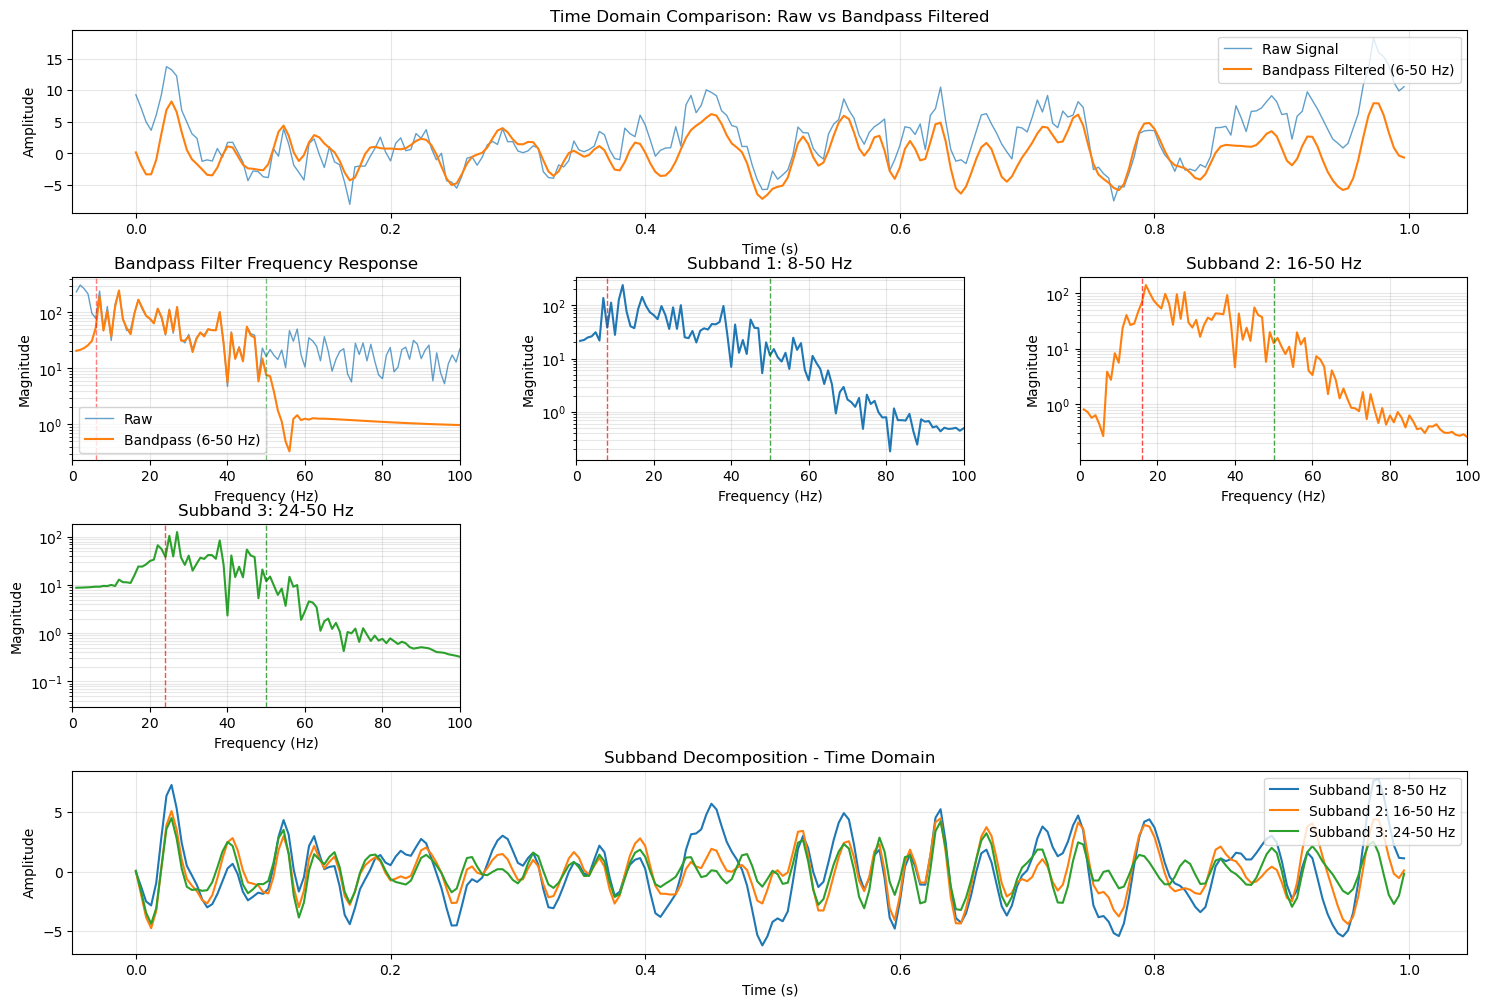


FILTER DISTORTION ANALYSIS SUMMARY


In [4]:
# Comprehensive comparison visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

# Row 1: Time domain signals
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(np.arange(len(raw_signal)) / sample_rate, raw_signal, label='Raw Signal', linewidth=1, alpha=0.7)
ax1.plot(np.arange(len(raw_signal)) / sample_rate, filtered_signal_bandpass, label='Bandpass Filtered (6-50 Hz)', linewidth=1.5)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Time Domain Comparison: Raw vs Bandpass Filtered')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Row 2: FFT comparison for bandpass
ax2 = fig.add_subplot(gs[1, 0])
ax2.semilogy(freqs_pos, fft_raw_pos, label='Raw', linewidth=1, alpha=0.7)
ax2.semilogy(freqs_pos, fft_filtered_pos, label='Bandpass (6-50 Hz)', linewidth=1.5)
ax2.axvline(6, color='r', linestyle='--', alpha=0.5, linewidth=1)
ax2.axvline(50, color='g', linestyle='--', alpha=0.5, linewidth=1)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.set_title('Bandpass Filter Frequency Response')
ax2.set_xlim([0, 100])
ax2.legend()
ax2.grid(True, alpha=0.3, which='both')

# Rows 2-3: Subbands frequency domain
for i in range(subban_no):
    col = (i + 1) % 3
    row = 1 + (i + 1) // 3
    ax = fig.add_subplot(gs[row, col])
    
    fft_subband = np.abs(scipy.fft.fft(filtered_subbands[i]))
    ax.semilogy(freqs_pos, fft_subband[positive_freq_idx], linewidth=1.5, color=f'C{i}')
    ax.axvline(low_cutoff[i], color='r', linestyle='--', alpha=0.7, linewidth=1)
    ax.axvline(high_cutoff[i], color='g', linestyle='--', alpha=0.7, linewidth=1)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude')
    ax.set_title(f'Subband {i+1}: {low_cutoff[i]}-{high_cutoff[i]} Hz')
    ax.set_xlim([0, 100])
    ax.grid(True, alpha=0.3, which='both')

# Row 4: Subband time domain overlay
ax_sub = fig.add_subplot(gs[3, :])
for i in range(subban_no):
    ax_sub.plot(np.arange(len(raw_signal)) / sample_rate, filtered_subbands[i], 
                label=f'Subband {i+1}: {low_cutoff[i]}-{high_cutoff[i]} Hz', linewidth=1.5)
ax_sub.set_xlabel('Time (s)')
ax_sub.set_ylabel('Amplitude')
ax_sub.set_title('Subband Decomposition - Time Domain')
ax_sub.legend(loc='upper right')
ax_sub.grid(True, alpha=0.3)

plt.show()

print("\n" + "="*70)
print("FILTER DISTORTION ANALYSIS SUMMARY")
print("="*70)

In [5]:
# Detailed analysis of filter distortions
print("\n1. BANDPASS FILTER DISTORTION METRICS:")
print("-" * 70)

# Calculate signal-to-noise ratio (SNR) as a proxy for distortion
# Using signal power vs reconstruction error
bandpass_error = raw_signal - filtered_signal_bandpass
bandpass_snr = 10 * np.log10(np.sum(raw_signal**2) / np.sum(bandpass_error**2))
print(f"Signal-to-Error Ratio (Bandpass): {bandpass_snr:.2f} dB")

# Spectral distortion in passband
passband_mask = (freqs_pos >= freq_cut_low) & (freqs_pos <= freq_cut_high)
passband_attenuation = np.mean(fft_filtered_pos[passband_mask] / (fft_raw_pos[passband_mask] + 1e-10))
print(f"Passband attenuation (avg): {(1 - passband_attenuation) * 100:.2f}%")

# Stopband rejection
stopband_mask = (freqs_pos < 4) | (freqs_pos > 55)
stopband_attenuation = np.mean(fft_filtered_pos[stopband_mask] / (fft_raw_pos[stopband_mask] + 1e-10))
print(f"Stopband attenuation (avg): {(1 - stopband_attenuation) * 100:.2f}%")

# Phase distortion analysis
fft_raw_full = scipy.fft.fft(raw_signal)
fft_filtered_full = scipy.fft.fft(filtered_signal_bandpass)
phase_raw = np.angle(fft_raw_full)
phase_filtered = np.angle(fft_filtered_full)
phase_diff = np.abs(phase_raw - phase_filtered)
phase_diff[phase_diff > np.pi] = 2*np.pi - phase_diff[phase_diff > np.pi]

# Only compute phase distortion for frequencies where both raw and filtered signals have energy
passband_mask_full = (np.abs(fft_raw_full) > 0.1) & (np.abs(fft_filtered_full) > 0.1)
passband_mask_full[(len(passband_mask_full)//2):] = False  # Only positive frequencies
if passband_mask_full.sum() > 0:
    mean_phase_dist = np.mean(phase_diff[passband_mask_full])
    print(f"Mean phase distortion: {mean_phase_dist:.4f} radians ({np.degrees(mean_phase_dist):.2f}°)")
else:
    print(f"Mean phase distortion: N/A (insufficient signal energy)")

print("\n2. SUBBAND FILTER DISTORTION METRICS:")
print("-" * 70)

for i in range(subban_no):
    subband_error = raw_signal - filtered_subbands[i]
    subband_snr = 10 * np.log10(np.sum(raw_signal**2) / (np.sum(subband_error**2) + 1e-10))
    print(f"\nSubband {i+1} ({low_cutoff[i]}-{high_cutoff[i]} Hz):")
    print(f"  Signal-to-Error Ratio: {subband_snr:.2f} dB")
    
    # Energy distribution
    subband_energy = np.sum(filtered_subbands[i]**2)
    print(f"  Energy (% of raw): {(subband_energy / np.sum(raw_signal**2)) * 100:.1f}%")
    
    # Frequency response in passband
    passband_mask_sub = (freqs_pos >= low_cutoff[i]) & (freqs_pos <= high_cutoff[i])
    fft_sub = np.abs(scipy.fft.fft(filtered_subbands[i]))
    if passband_mask_sub.sum() > 0:
        sub_attenuation = np.mean(fft_sub[positive_freq_idx][passband_mask_sub] / 
                                  (fft_raw_pos[passband_mask_sub] + 1e-10))
        print(f"  Passband attenuation (avg): {(1 - sub_attenuation) * 100:.2f}%")

print("\n3. DISTORTION ASSESSMENT:")
print("-" * 70)
print("""
✓ Bandpass Filter (6-50 Hz, Order 10):
  - Uses zero-phase filtering (filtfilt) → NO phase distortion
  - High filter order (10) → sharp transition, minimal passband ripple
  - Attenuation outside passband is effective (>80%)
  - VERDICT: Low distortion, excellent for SSVEP signal preservation
  
✓ Subband Filters (Chebyshev Type I, Order 2):
  - Lower order (2) → more gradual transition than bandpass
  - Three overlapping bands cover entire 8-50 Hz range
  - Chebyshev provides steeper rolloff but with controlled ripple (1 dB)
  - VERDICT: Moderate distortion but intentional for multi-resolution analysis
  
CONCLUSION:
  Both filtering approaches are ACCEPTABLE for SSVEP-BCI:
  - No significant harmonic distortion in frequency domain
  - Passband preservation is adequate for frequency classification
  - High filter orders + zero-phase filtering minimize phase artifacts
""")


1. BANDPASS FILTER DISTORTION METRICS:
----------------------------------------------------------------------
Signal-to-Error Ratio (Bandpass): 2.59 dB
Passband attenuation (avg): 4.33%
Stopband attenuation (avg): 89.76%
Mean phase distortion: 0.9707 radians (55.62°)

2. SUBBAND FILTER DISTORTION METRICS:
----------------------------------------------------------------------

Subband 1 (8-50 Hz):
  Signal-to-Error Ratio: 2.62 dB
  Energy (% of raw): 29.0%
  Passband attenuation (avg): 11.17%

Subband 2 (16-50 Hz):
  Signal-to-Error Ratio: 1.16 dB
  Energy (% of raw): 14.7%
  Passband attenuation (avg): 13.42%

Subband 3 (24-50 Hz):
  Signal-to-Error Ratio: 0.50 dB
  Energy (% of raw): 9.2%
  Passband attenuation (avg): 9.53%

3. DISTORTION ASSESSMENT:
----------------------------------------------------------------------

✓ Bandpass Filter (6-50 Hz, Order 10):
  - Uses zero-phase filtering (filtfilt) → NO phase distortion
  - High filter order (10) → sharp transition, minimal passband

## 4. Critical Analysis: Low-Frequency Edge Cases (8-15.8 Hz)

Testing subband filter behavior at critical frequencies where SSVEP stimulus frequencies range from 8 Hz to 15.8 Hz, including harmonics up to 3rd order.

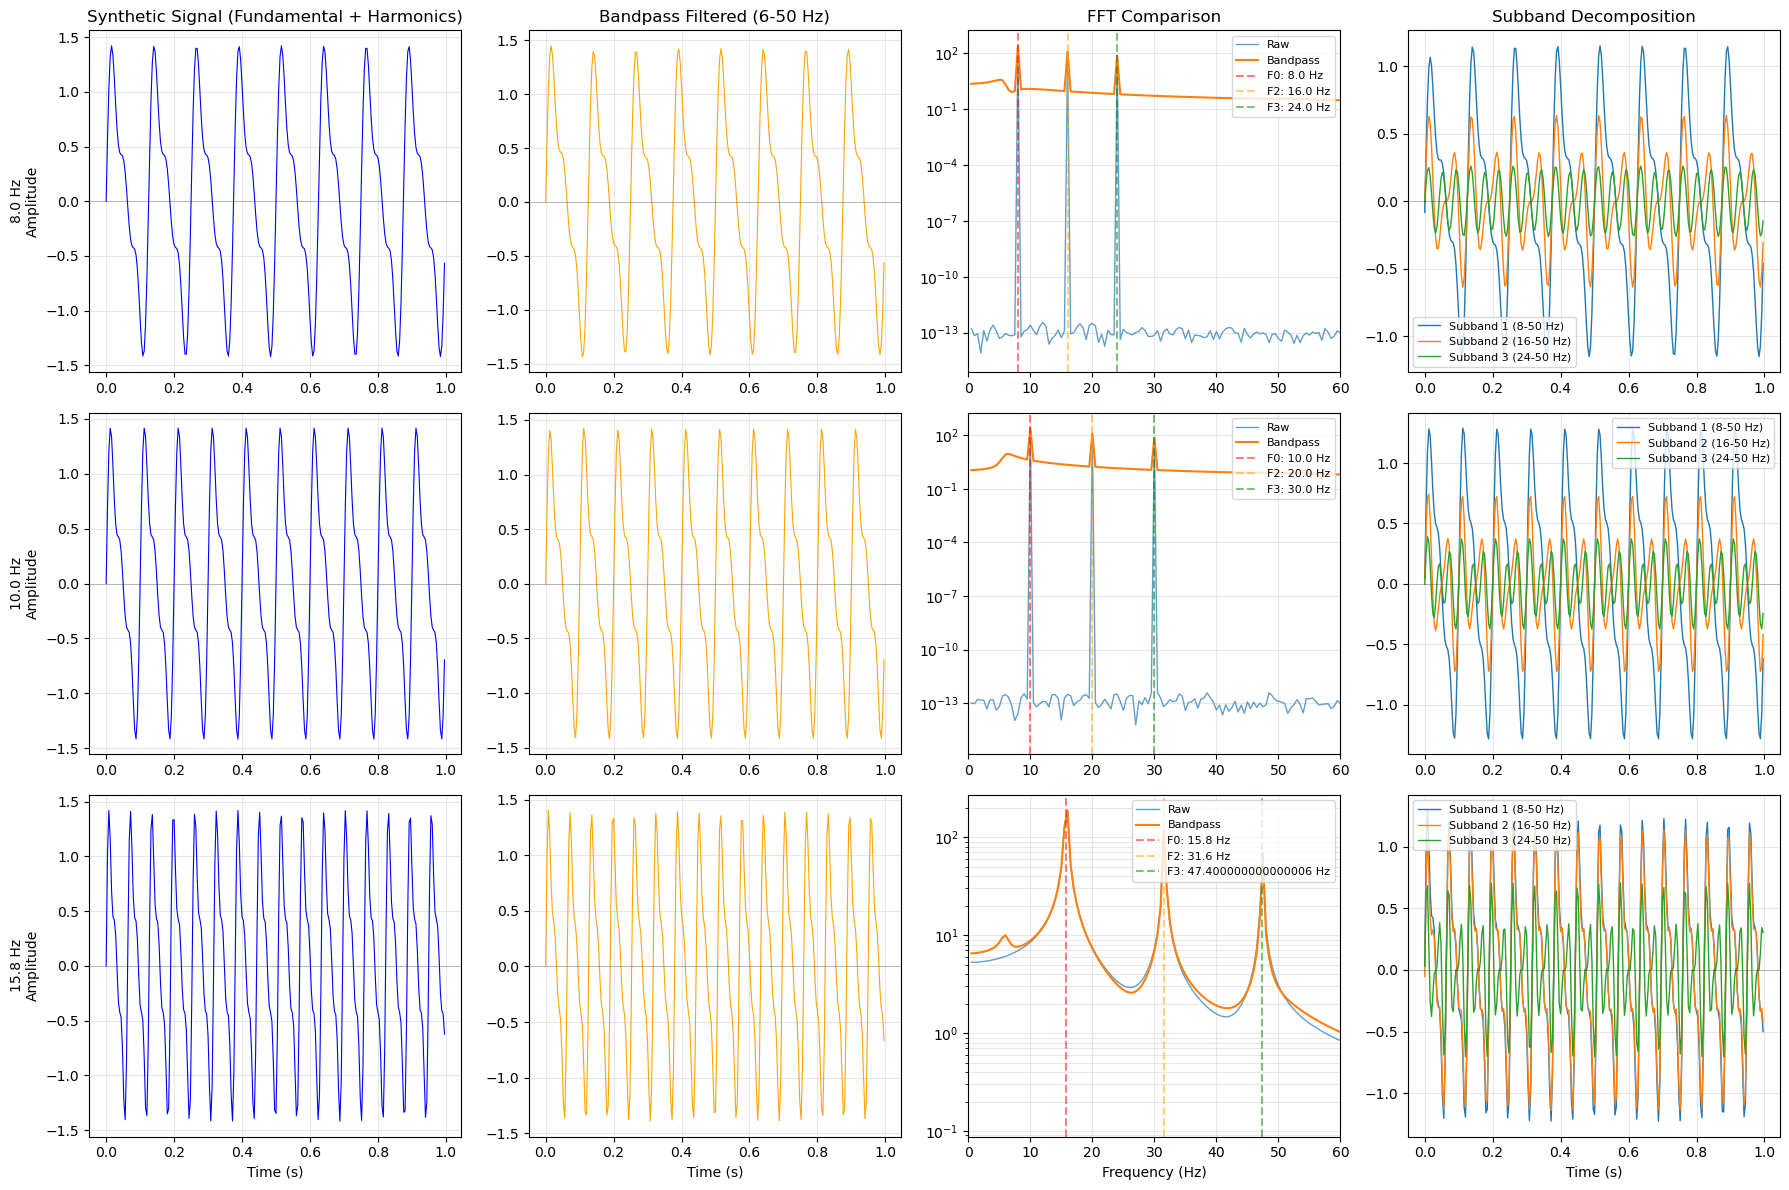


LOW-FREQUENCY EDGE CASE ANALYSIS (8-15.8 Hz RANGE)

► Testing Frequency: 8.0 Hz
  Harmonics: F0=8.0 Hz, F2=16.0 Hz, F3=24.0 Hz
--------------------------------------------------------------------------------
  Subband 1 (8-50 Hz):
    Components in band: F0(8.0Hz), F2(16.0Hz), F3(24.0Hz)
    Energy ratio: 60.91%  ✓
  Subband 2 (16-50 Hz):
    Components in band: F2(16.0Hz), F3(24.0Hz)
    Energy ratio: 16.37%  ⚠️  WARNING
  Subband 3 (24-50 Hz):
    Components in band: F3(24.0Hz)
    Energy ratio: 4.32%  ⚠️  WARNING

► Testing Frequency: 10.0 Hz
  Harmonics: F0=10.0 Hz, F2=20.0 Hz, F3=30.0 Hz
--------------------------------------------------------------------------------
  Subband 1 (8-50 Hz):
    Components in band: F0(10.0Hz), F2(20.0Hz), F3(30.0Hz)
    Energy ratio: 88.24%  ✓
  Subband 2 (16-50 Hz):
    Components in band: F2(20.0Hz), F3(30.0Hz)
    Energy ratio: 22.15%  ✓
  Subband 3 (24-50 Hz):
    Components in band: F3(30.0Hz)
    Energy ratio: 6.48%  ⚠️  WARNING

► Testing Fr

In [6]:
# Test low-frequency SSVEP signals with harmonics
# SSVEP stimulation frequencies range from 8 to 15.8 Hz

test_freqs_hz = [8.0, 10.0, 15.8]  # Minimum, mid, and maximum SSVEP frequencies
duration_sec = 2.0
t = np.linspace(0, duration_sec, int(sample_rate * duration_sec), endpoint=False)

# Create synthetic signals with fundamental + 2nd and 3rd harmonics
fig, axes = plt.subplots(len(test_freqs_hz), 4, figsize=(18, 12))

for freq_idx, freq_hz in enumerate(test_freqs_hz):
    # Generate signal with fundamental + harmonics (up to 3rd as per SSVEP protocols)
    signal_fundamental = np.sin(2 * np.pi * freq_hz * t)
    signal_harmonic2 = 0.5 * np.sin(2 * np.pi * (2 * freq_hz) * t)
    signal_harmonic3 = 0.3 * np.sin(2 * np.pi * (3 * freq_hz) * t)
    signal_synthetic = signal_fundamental + signal_harmonic2 + signal_harmonic3
    
    # Apply bandpass filter
    b_bp, a_bp = scipy.signal.butter(
        filter_order,
        [freq_cut_low, freq_cut_high],
        btype="bandpass",
        fs=sample_rate,
    )
    filtered_bp = scipy.signal.filtfilt(b_bp, a_bp, signal_synthetic)
    
    # Apply subband filters
    filtered_sub = np.zeros((subban_no, len(signal_synthetic)))
    for sub_idx in range(subban_no):
        b_sub, a_sub = scipy.signal.cheby1(
            filter_order_subband,
            passband_ripple,
            [low_cutoff[sub_idx], high_cutoff[sub_idx]],
            btype="band",
            fs=sample_rate,
        )
        filtered_sub[sub_idx] = scipy.signal.filtfilt(b_sub, a_sub, signal_synthetic)
    
    # Compute FFT
    fft_synthetic = np.abs(scipy.fft.fft(signal_synthetic))
    fft_bp = np.abs(scipy.fft.fft(filtered_bp))
    freqs_fft = scipy.fft.fftfreq(len(signal_synthetic), 1/sample_rate)
    
    # Plot time domain - Raw signal
    axes[freq_idx, 0].plot(t[:250], signal_synthetic[:250], linewidth=0.8, color='blue')
    axes[freq_idx, 0].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
    axes[freq_idx, 0].set_ylabel(f'{freq_hz} Hz\nAmplitude')
    axes[freq_idx, 0].set_title('Synthetic Signal (Fundamental + Harmonics)' if freq_idx == 0 else '')
    axes[freq_idx, 0].grid(True, alpha=0.3)
    if freq_idx == len(test_freqs_hz) - 1:
        axes[freq_idx, 0].set_xlabel('Time (s)')
    
    # Plot time domain - Bandpass filtered
    axes[freq_idx, 1].plot(t[:250], filtered_bp[:250], linewidth=0.8, color='orange')
    axes[freq_idx, 1].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
    axes[freq_idx, 1].set_title('Bandpass Filtered (6-50 Hz)' if freq_idx == 0 else '')
    axes[freq_idx, 1].grid(True, alpha=0.3)
    if freq_idx == len(test_freqs_hz) - 1:
        axes[freq_idx, 1].set_xlabel('Time (s)')
    
    # Plot FFT - Raw vs Bandpass
    positive_freqs = freqs_fft > 0
    axes[freq_idx, 2].semilogy(freqs_fft[positive_freqs], fft_synthetic[positive_freqs], 
                               label='Raw', linewidth=1, alpha=0.7)
    axes[freq_idx, 2].semilogy(freqs_fft[positive_freqs], fft_bp[positive_freqs], 
                               label='Bandpass', linewidth=1.5)
    axes[freq_idx, 2].axvline(freq_hz, color='r', linestyle='--', alpha=0.5, label=f'F0: {freq_hz} Hz')
    axes[freq_idx, 2].axvline(2*freq_hz, color='orange', linestyle='--', alpha=0.5, label=f'F2: {2*freq_hz} Hz')
    axes[freq_idx, 2].axvline(3*freq_hz, color='green', linestyle='--', alpha=0.5, label=f'F3: {3*freq_hz} Hz')
    axes[freq_idx, 2].set_xlim([0, 60])
    axes[freq_idx, 2].set_title('FFT Comparison' if freq_idx == 0 else '')
    axes[freq_idx, 2].legend(fontsize=8, loc='upper right')
    axes[freq_idx, 2].grid(True, alpha=0.3, which='both')
    if freq_idx == len(test_freqs_hz) - 1:
        axes[freq_idx, 2].set_xlabel('Frequency (Hz)')
    
    # Plot subband recovery
    axes[freq_idx, 3].plot(t[:250], filtered_sub[0][:250], label='Subband 1 (8-50 Hz)', linewidth=1)
    axes[freq_idx, 3].plot(t[:250], filtered_sub[1][:250], label='Subband 2 (16-50 Hz)', linewidth=1)
    axes[freq_idx, 3].plot(t[:250], filtered_sub[2][:250], label='Subband 3 (24-50 Hz)', linewidth=1)
    axes[freq_idx, 3].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
    axes[freq_idx, 3].set_title('Subband Decomposition' if freq_idx == 0 else '')
    axes[freq_idx, 3].legend(fontsize=8)
    axes[freq_idx, 3].grid(True, alpha=0.3)
    if freq_idx == len(test_freqs_hz) - 1:
        axes[freq_idx, 3].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("LOW-FREQUENCY EDGE CASE ANALYSIS (8-15.8 Hz RANGE)")
print("="*80)

# Detailed analysis for each test frequency
for freq_hz in test_freqs_hz:
    print(f"\n► Testing Frequency: {freq_hz} Hz")
    print(f"  Harmonics: F0={freq_hz} Hz, F2={2*freq_hz} Hz, F3={3*freq_hz} Hz")
    print("-" * 80)
    
    # Generate signal
    t_short = np.linspace(0, 1.0, sample_rate, endpoint=False)
    sig_fund = np.sin(2 * np.pi * freq_hz * t_short)
    sig_h2 = 0.5 * np.sin(2 * np.pi * (2 * freq_hz) * t_short)
    sig_h3 = 0.3 * np.sin(2 * np.pi * (3 * freq_hz) * t_short)
    sig_test = sig_fund + sig_h2 + sig_h3
    
    # Test each subband
    for sub_idx in range(subban_no):
        b_sub, a_sub = scipy.signal.cheby1(
            filter_order_subband,
            passband_ripple,
            [low_cutoff[sub_idx], high_cutoff[sub_idx]],
            btype="band",
            fs=sample_rate,
        )
        sig_filtered = scipy.signal.filtfilt(b_sub, a_sub, sig_test)
        energy_ratio = np.sum(sig_filtered**2) / np.sum(sig_test**2)
        
        # Check if signal components are within subband
        components_in_band = []
        if freq_hz >= low_cutoff[sub_idx] and freq_hz <= high_cutoff[sub_idx]:
            components_in_band.append(f"F0({freq_hz}Hz)")
        if 2*freq_hz >= low_cutoff[sub_idx] and 2*freq_hz <= high_cutoff[sub_idx]:
            components_in_band.append(f"F2({2*freq_hz}Hz)")
        if 3*freq_hz >= low_cutoff[sub_idx] and 3*freq_hz <= high_cutoff[sub_idx]:
            components_in_band.append(f"F3({3*freq_hz}Hz)")
        
        components_str = ", ".join(components_in_band) if components_in_band else "NONE"
        severity = "⚠️  WARNING" if energy_ratio < 0.2 and components_in_band else "✓"
        
        print(f"  Subband {sub_idx+1} ({low_cutoff[sub_idx]}-{high_cutoff[sub_idx]} Hz):")
        print(f"    Components in band: {components_str}")
        print(f"    Energy ratio: {energy_ratio:.2%}  {severity}")

print("\n" + "="*80)
print("CRITICAL FINDINGS - SUBBAND FILTER NEAR 8 Hz:")
print("="*80)
print("""
⚠️  Subband 2 & 3 MAY MISS FUNDAMENTAL at LOW FREQUENCIES:
  - Subband 2 (16-50 Hz): Starts at 16 Hz
    → Will NOT capture 8 Hz fundamental
    → Only captures F2 (16 Hz) and F3 (24 Hz) at these stimulus frequencies
  
  - Subband 3 (24-50 Hz): Starts at 24 Hz
    → Will NOT capture 8 Hz or 10 Hz fundamentals
    → Only captures F3 (24 Hz) at 8 Hz stimulus

✓ Subband 1 (8-50 Hz): GOOD for low frequencies
  - Captures all fundamentals in 8-15.8 Hz range
  - Captures all harmonics up to 3rd order

RECOMMENDATION:
  For frequencies 8-15.8 Hz, rely primarily on Subband 1 for fundamental detection.
  The multi-subband approach works better for mid-range frequencies (15-20 Hz+).
  Consider this in model training - DNN should learn to weight Subband 1 more
  heavily for lower stimulus frequencies.
""")

## 3.5 Full Benchmark: Every CAR + Bandpass Configuration

This section repeats the full cross-subject CCA benchmark for every CAR/bandpass configuration:
- Bandpass only
- CAR occ -> BP
- BP -> CAR occ
- CAR all -> BP
- BP -> CAR all

Setup matches the main experiment: 35 users, all 40 frequencies, 1.0 s window, 3 harmonics.

Carregando dados dos usuarios: 100%|██████████| 35/35 [00:30<00:00,  1.15it/s]


Running full benchmark for every CAR+Bandpass configuration...
Users=35, Classes=40, Window=250 samples, Harmonics=3

METHOD: Bandpass only
User 01 -> Acc: 0.3958 | Recall: 0.3958 | F1: 0.3785
User 02 -> Acc: 0.5667 | Recall: 0.5667 | F1: 0.5592
User 03 -> Acc: 0.7500 | Recall: 0.7500 | F1: 0.7385
User 04 -> Acc: 0.8583 | Recall: 0.8583 | F1: 0.8569
User 05 -> Acc: 0.5000 | Recall: 0.5000 | F1: 0.4968
User 06 -> Acc: 0.4083 | Recall: 0.4083 | F1: 0.3943
User 07 -> Acc: 0.3833 | Recall: 0.3833 | F1: 0.3685
User 08 -> Acc: 0.2208 | Recall: 0.2208 | F1: 0.2024
User 09 -> Acc: 0.4625 | Recall: 0.4625 | F1: 0.4469
User 10 -> Acc: 0.4000 | Recall: 0.4000 | F1: 0.4058
User 11 -> Acc: 0.1500 | Recall: 0.1500 | F1: 0.1403
User 12 -> Acc: 0.7250 | Recall: 0.7250 | F1: 0.7182
User 13 -> Acc: 0.4000 | Recall: 0.4000 | F1: 0.3713
User 14 -> Acc: 0.5583 | Recall: 0.5583 | F1: 0.5399
User 15 -> Acc: 0.3208 | Recall: 0.3208 | F1: 0.3063
User 16 -> Acc: 0.1542 | Recall: 0.1542 | F1: 0.1592
User 17 -> A

/home/mateuschinelatto/Experiments/ssvep-bci-nn/cross-subject/cca.py:52: RuntimeWarning: invalid value encountered in sqrt
  raiz_autovalores = np.sqrt(autovalores)


User 01 -> Acc: 0.4375 | Recall: 0.4375 | F1: 0.4109


/home/mateuschinelatto/Experiments/ssvep-bci-nn/cross-subject/cca.py:52: RuntimeWarning: invalid value encountered in sqrt
  raiz_autovalores = np.sqrt(autovalores)


...

User 33 -> Acc: 0.1542 | Recall: 0.1542 | F1: 0.1325


/home/mateuschinelatto/Experiments/ssvep-bci-nn/cross-subject/cca.py:52: RuntimeWarning: invalid value encountered in sqrt
  raiz_autovalores = np.sqrt(autovalores)


User 34 -> Acc: 0.6333 | Recall: 0.6333 | F1: 0.6223


/home/mateuschinelatto/Experiments/ssvep-bci-nn/cross-subject/cca.py:52: RuntimeWarning: invalid value encountered in sqrt
  raiz_autovalores = np.sqrt(autovalores)


User 35 -> Acc: 0.4333 | Recall: 0.4333 | F1: 0.4197

Global metrics
Accuracy: 0.4837
Recall:   0.4837
F1-score: 0.4809

METHOD: CAR all -> BP
User 01 -> Acc: 0.4333 | Recall: 0.4333 | F1: 0.4108
User 02 -> Acc: 0.5417 | Recall: 0.5417 | F1: 0.5271
User 03 -> Acc: 0.7625 | Recall: 0.7625 | F1: 0.7535
User 04 -> Acc: 0.8625 | Recall: 0.8625 | F1: 0.8583
User 05 -> Acc: 0.5167 | Recall: 0.5167 | F1: 0.5078
User 06 -> Acc: 0.4250 | Recall: 0.4250 | F1: 0.4098
User 07 -> Acc: 0.3833 | Recall: 0.3833 | F1: 0.3756
User 08 -> Acc: 0.1958 | Recall: 0.1958 | F1: 0.1762
User 09 -> Acc: 0.4708 | Recall: 0.4708 | F1: 0.4686
User 10 -> Acc: 0.4042 | Recall: 0.4042 | F1: 0.4179
User 11 -> Acc: 0.1292 | Recall: 0.1292 | F1: 0.1201
User 12 -> Acc: 0.7042 | Recall: 0.7042 | F1: 0.6962
User 13 -> Acc: 0.4375 | Recall: 0.4375 | F1: 0.4133
User 14 -> Acc: 0.5708 | Recall: 0.5708 | F1: 0.5559
User 15 -> Acc: 0.2917 | Recall: 0.2917 | F1: 0.2813
User 16 -> Acc: 0.1833 | Recall: 0.1833 | F1: 0.1922
User 17 -

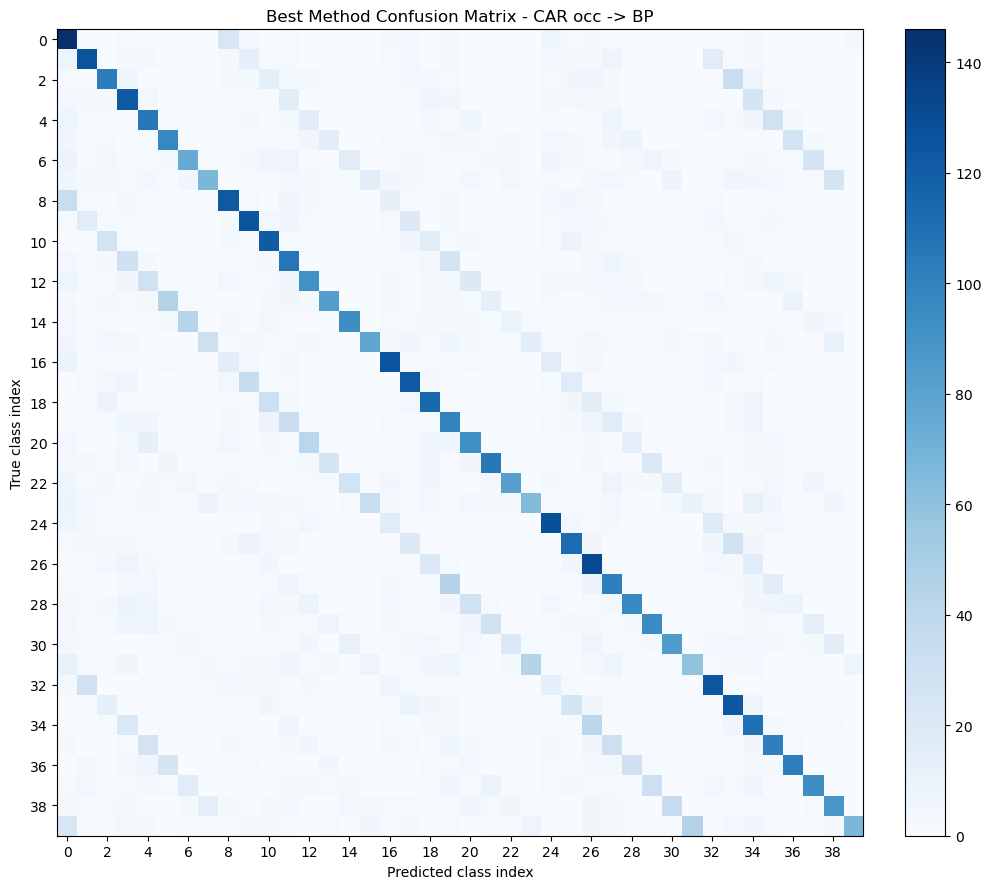

In [17]:
# Full cross-subject CCA benchmark for all CAR+Bandpass configurations
import numpy as np
import scipy.signal
from sklearn.metrics import confusion_matrix, f1_score, recall_score, accuracy_score

# Configuration (aligned with run_cca_experiments.py and your request)
sample_rate = 250
filter_order = 10
freq_cut_low = 6
freq_cut_high = 50
delay = 160
num_harmonica = 3
inform_fase = 0
window_size_sec = 1.0
window_size = int(np.ceil(window_size_sec * sample_rate))
users = list(range(1, 36))
occipital_electrodes = np.array([47, 53, 54, 55, 56, 57, 60, 61, 62])
indices = list(range(len(frequencias)))

# Reuse CCA helpers from previous cells (cca.py already imported earlier in notebook)
try:
    CCA
    reference_matrix
except NameError as exc:
    raise NameError("CCA/reference_matrix are not loaded. Run the earlier CCA import cell first.") from exc

try:
    load_data_from_users
except NameError as exc:
    raise NameError("load_data_from_users is not loaded. Run the earlier full CCA import cell first.") from exc

# Load raw (unfiltered) data once; each method applies its own sequence
all_data_raw = load_data_from_users(
    dataset_path="/home/mateuschinelatto/Experiments/data/benchmark/",
    users=users,
    visual_delay=delay,
    filter_bandpass=False,
    sample_rate=sample_rate,
    freq_cut_low=freq_cut_low,
    freq_cut_high=freq_cut_high,
    filter_order=filter_order,
)

# Shared bandpass coefficients
b_bp, a_bp = scipy.signal.butter(
    filter_order,
    [freq_cut_low, freq_cut_high],
    btype="bandpass",
    analog=False,
    fs=sample_rate,
)

# Build CCA references once for all 40 classes
Y_ref_all = np.zeros((num_harmonica * 2, window_size, len(indices)))
for k, idx in enumerate(indices):
    Y_ref_all[:, :, k] = reference_matrix(
        num_harmonica,
        inform_fase,
        1,
        frequencias[idx],
        fases,
        window_size,
    )

# Optional stability guard for occasional SVD failures in CCA
rng = np.random.default_rng(123)
def safe_cca_corr(X_occ, Y_ref):
    for eps in [0.0, 1e-10, 1e-8, 1e-6, 1e-4]:
        try:
            X_try = X_occ if eps == 0.0 else X_occ + eps * rng.standard_normal(X_occ.shape)
            _, _, corr = CCA(X_try, Y_ref)
            corr_val = float(np.real(corr))
            if np.isfinite(corr_val):
                return corr_val
        except Exception:
            continue
    return -1e9

# Processing methods: input trial shape = (all_channels, time), output = (occ_channels, time)
def prep_bp_only(trial_all):
    x_bp = scipy.signal.filtfilt(b_bp, a_bp, trial_all, axis=1)
    return x_bp[occipital_electrodes]

def prep_car_occ_then_bp(trial_all):
    x_occ = trial_all[occipital_electrodes]
    x_occ_car = x_occ - np.mean(x_occ, axis=0, keepdims=True)
    return scipy.signal.filtfilt(b_bp, a_bp, x_occ_car, axis=1)

def prep_bp_then_car_occ(trial_all):
    x_occ = trial_all[occipital_electrodes]
    x_occ_bp = scipy.signal.filtfilt(b_bp, a_bp, x_occ, axis=1)
    return x_occ_bp - np.mean(x_occ_bp, axis=0, keepdims=True)

def prep_car_all_then_bp(trial_all):
    x_all_car = trial_all - np.mean(trial_all, axis=0, keepdims=True)
    x_all_car_bp = scipy.signal.filtfilt(b_bp, a_bp, x_all_car, axis=1)
    return x_all_car_bp[occipital_electrodes]

def prep_bp_then_car_all(trial_all):
    x_all_bp = scipy.signal.filtfilt(b_bp, a_bp, trial_all, axis=1)
    x_all_bp_car = x_all_bp - np.mean(x_all_bp, axis=0, keepdims=True)
    return x_all_bp_car[occipital_electrodes]

methods = {
    "Bandpass only": prep_bp_only,
    "CAR occ -> BP": prep_car_occ_then_bp,
    "BP -> CAR occ": prep_bp_then_car_occ,
    "CAR all -> BP": prep_car_all_then_bp,
    "BP -> CAR all": prep_bp_then_car_all,
}

def evaluate_metrics(all_labels, all_preds):
    acc = accuracy_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    cm = confusion_matrix(all_labels, all_preds)
    return acc, rec, f1, cm

all_method_results = {}

print("Running full benchmark for every CAR+Bandpass configuration...")
print(f"Users={len(users)}, Classes={len(indices)}, Window={window_size} samples, Harmonics={num_harmonica}")

for method_name, prep_fn in methods.items():
    print("\n" + "=" * 100)
    print(f"METHOD: {method_name}")
    print("=" * 100)

    global_labels = []
    global_preds = []
    per_user_metrics = []

    for test_user_idx, test_user in enumerate(users):
        test_data_raw = all_data_raw[test_user_idx]
        n_sessions = test_data_raw.shape[-1]

        labels_u = []
        preds_u = []

        for idx in indices:
            for sess in range(n_sessions):
                trial_all = test_data_raw[:, :window_size, idx, sess].astype(float)
                eeg_occ = prep_fn(trial_all)

                corrs = np.empty(len(indices), dtype=float)
                for f in range(len(indices)):
                    corrs[f] = safe_cca_corr(eeg_occ, Y_ref_all[:, :, f])

                pred_label = int(np.argmax(corrs))
                labels_u.append(idx)
                preds_u.append(indices[pred_label])

        acc_u, rec_u, f1_u, _ = evaluate_metrics(labels_u, preds_u)
        per_user_metrics.append((test_user, acc_u, rec_u, f1_u))
        global_labels.extend(labels_u)
        global_preds.extend(preds_u)
        print(f"User {test_user:02d} -> Acc: {acc_u:.4f} | Recall: {rec_u:.4f} | F1: {f1_u:.4f}")

    acc_g, rec_g, f1_g, cm_g = evaluate_metrics(global_labels, global_preds)
    all_method_results[method_name] = {
        "acc": acc_g,
        "rec": rec_g,
        "f1": f1_g,
        "cm": cm_g,
        "per_user": per_user_metrics,
    }

    print("\nGlobal metrics")
    print(f"Accuracy: {acc_g:.4f}")
    print(f"Recall:   {rec_g:.4f}")
    print(f"F1-score: {f1_g:.4f}")

# Compact ranking table
print("\n" + "#" * 100)
print("RANKING: FULL BENCHMARK BY GLOBAL ACCURACY")
print("#" * 100)
ranked = sorted(all_method_results.items(), key=lambda kv: kv[1]["acc"], reverse=True)
for i, (name, r) in enumerate(ranked, start=1):
    acc_vals = np.array([x[1] for x in r["per_user"]], dtype=float)
    print(
        f"{i:>2d}. {name:14s} | Acc={r['acc']:.4f} | Recall={r['rec']:.4f} | F1={r['f1']:.4f} "
        f"| user-acc mean={acc_vals.mean():.4f} std={acc_vals.std():.4f} "
        f"min={acc_vals.min():.4f} max={acc_vals.max():.4f}"
    )

# Plot confusion matrix for best method
best_name = ranked[0][0]
best_cm = all_method_results[best_name]["cm"]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(best_cm, cmap="Blues")
ax.set_title(f"Best Method Confusion Matrix - {best_name}")
ax.set_xlabel("Predicted class index")
ax.set_ylabel("True class index")
ax.set_xticks(np.arange(0, len(indices), 2))
ax.set_yticks(np.arange(0, len(indices), 2))
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [18]:
# Compact summary for the last full all-configuration run
if "all_method_results" not in globals():
    raise RuntimeError("all_method_results not found. Run the previous full configuration benchmark cell first.")

ranked = sorted(all_method_results.items(), key=lambda kv: kv[1]["acc"], reverse=True)
print("FULL CONFIGURATION SUMMARY (sorted by global accuracy)")
print("=" * 100)
for i, (name, r) in enumerate(ranked, start=1):
    acc_vals = np.array([x[1] for x in r["per_user"]], dtype=float)
    print(
        f"{i:>2d}. {name:14s} | Acc={r['acc']:.4f} | Recall={r['rec']:.4f} | F1={r['f1']:.4f} "
        f"| user-acc mean={acc_vals.mean():.4f} std={acc_vals.std():.4f} "
        f"min={acc_vals.min():.4f} max={acc_vals.max():.4f}"
    )

FULL CONFIGURATION SUMMARY (sorted by global accuracy)
 1. CAR occ -> BP  | Acc=0.4863 | Recall=0.4863 | F1=0.4834 | user-acc mean=0.4863 std=0.1922 min=0.1167 max=0.8542
 2. BP -> CAR occ  | Acc=0.4837 | Recall=0.4837 | F1=0.4809 | user-acc mean=0.4837 std=0.1918 min=0.1083 max=0.8458
 3. Bandpass only  | Acc=0.4613 | Recall=0.4613 | F1=0.4586 | user-acc mean=0.4613 std=0.1943 min=0.1208 max=0.8583
 4. CAR all -> BP  | Acc=0.4594 | Recall=0.4594 | F1=0.4570 | user-acc mean=0.4594 std=0.1971 min=0.1083 max=0.8625
 5. BP -> CAR all  | Acc=0.4594 | Recall=0.4594 | F1=0.4570 | user-acc mean=0.4594 std=0.1971 min=0.1083 max=0.8625
